**Project Team ID** : PTID-CDS-NOV-25-3432 \
**Project Code** : PRCP-1006-HomeLoanDef \
**Project Name** : Home Loan Default

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import logging
warnings.filterwarnings("ignore")
logging.getLogger('matplotlib').setLevel(logging.WARNING)


import missingno as msno
from insightfulpy.eda import *


from sklearn.metrics import roc_curve, auc


pd.set_option('display.max_columns', None)
pd.set_option('display.width', 10000)
pd.set_option('display.max_colwidth', None)

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_colwidth', None)

In [3]:
application_train     = pd.read_csv('application_train.csv')
bureau                = pd.read_csv('bureau.csv')


In [4]:
print(f'Application data', application_train.shape)
print(f'Bureau data', bureau.shape)
# print(f'Bureau Balance data', bureau_balance.shape)
# print(f'Pos cash balance data', pos_cash_balance.shape)
# print(f'Credit Card data', credit_card_balance.shape)
# print(f'Previous Application data', previous_application.shape)
# print(f'Installments Payments data', installments_payments.shape)



Application data (307511, 122)
Bureau data (1716428, 17)


In [5]:
display("application_train")
display(application_train.head(3))
display("bureau")
display(bureau.head(3))
# display("bureau_balance")
# display(bureau_balance.head(3))
# display("credit_card_balance")
# display(credit_card_balance.head(3))
# display("installments_payments")
# display(installments_payments.head(3))
# display("pos_cash_balance")
# display(pos_cash_balance.head(3))
# display("previous_application")
# display(previous_application.head(3))

'application_train'

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

'bureau'

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN


In [6]:

column_to_check = ['NAME_CONTRACT_TYPE','NAME_TYPE_SUITE','NAME_INCOME_TYPE','NAME_FAMILY_STATUS','NAME_HOUSING_TYPE']

unique_values_summary = pd.DataFrame({
    'Column': column_to_check,
    'Unique_Count': [application_train[col].nunique() for col in column_to_check],
    'Unique_Values': [list(application_train[col].unique()) for col in column_to_check]
})

display(unique_values_summary)

,Column,Unique_Count,Unique_Values
0,NAME_CONTRACT_TYPE,2,"[Cash loans, Revolving loans]"
1,NAME_TYPE_SUITE,7,"[Unaccompanied, Family, Spouse, partner, Children, Other_A, nan, Other_B, Group of people]"
2,NAME_INCOME_TYPE,8,"[Working, State servant, Commercial associate, Pensioner, Unemployed, Student, Businessman, Maternity leave]"
3,NAME_FAMILY_STATUS,6,"[Single / not married, Married, Civil marriage, Widow, Separated, Unknown]"
4,NAME_HOUSING_TYPE,6,"[House / apartment, Rented apartment, With parents, Municipal apartment, Office apartment, Co-op apartment]"


Data Cleaning & Preprocessing

In [7]:
application_train.head(30)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.000,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0000,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.000,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0000,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.000,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [8]:
365243/365

1000.6657534246575

In [9]:
(application_train['DAYS_EMPLOYED']== 365243).sum()

55374

* 55374 time 365243 value is repeated in DAYS_EMPLOYED which mean 1000 year a person is employed
* this is bad data and this cannot be possible
* some values are in negative and some values are null value

In [10]:

application_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace=True)

Descriptive analysis

In [11]:
application_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,1.000020e+05,189145.500000,278202.000000,367142.500000,4.562550e+05
TARGET,307511.0,0.080729,0.272419,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
CNT_CHILDREN,307511.0,0.417052,0.722121,0.000000e+00,0.000000,0.000000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,2.565000e+04,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,4.500000e+04,270000.000000,513531.000000,808650.000000,4.050000e+06
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1.615500e+03,16524.000000,24903.000000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,4.050000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,0.020868,0.013831,2.900000e-04,0.010006,0.018850,0.028663,7.250800e-02
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-2.522900e+04,-19682.000000,-15750.000000,-12413.000000,-7.489000e+03
DAYS_EMPLOYED,252137.0,-2384.169325,2338.360162,-1.791200e+04,-3175.000000,-1648.000000,-767.000000,0.000000e+00


In [12]:
# converting negative DAYS into positive  

application_train['AGE_YEARS'] = application_train['DAYS_BIRTH'] / -365
application_train['YEAR_EMPLOYED'] = application_train['DAYS_EMPLOYED'] / -365
application_train['YEAR_REGISTRATION'] = application_train['DAYS_REGISTRATION'] / -365

In [13]:
application_train.drop(['DAYS_BIRTH','DAYS_EMPLOYED','DAYS_REGISTRATION'],axis=1, inplace=True)

In [14]:
missing_data = pd.DataFrame({
    'missing_percentage' : (((application_train.isnull().sum()) / len(application_train)) * 100)
}).sort_values('missing_percentage', ascending=False)
missing_data

,missing_percentage
COMMONAREA_AVG,69.872297
COMMONAREA_MEDI,69.872297
COMMONAREA_MODE,69.872297
NONLIVINGAPARTMENTS_MODE,69.432963
NONLIVINGAPARTMENTS_MEDI,69.432963
NONLIVINGAPARTMENTS_AVG,69.432963
FONDKAPREMONT_MODE,68.386172
LIVINGAPARTMENTS_MEDI,68.354953
LIVINGAPARTMENTS_AVG,68.354953
LIVINGAPARTMENTS_MODE,68.354953


Removing Missing columns

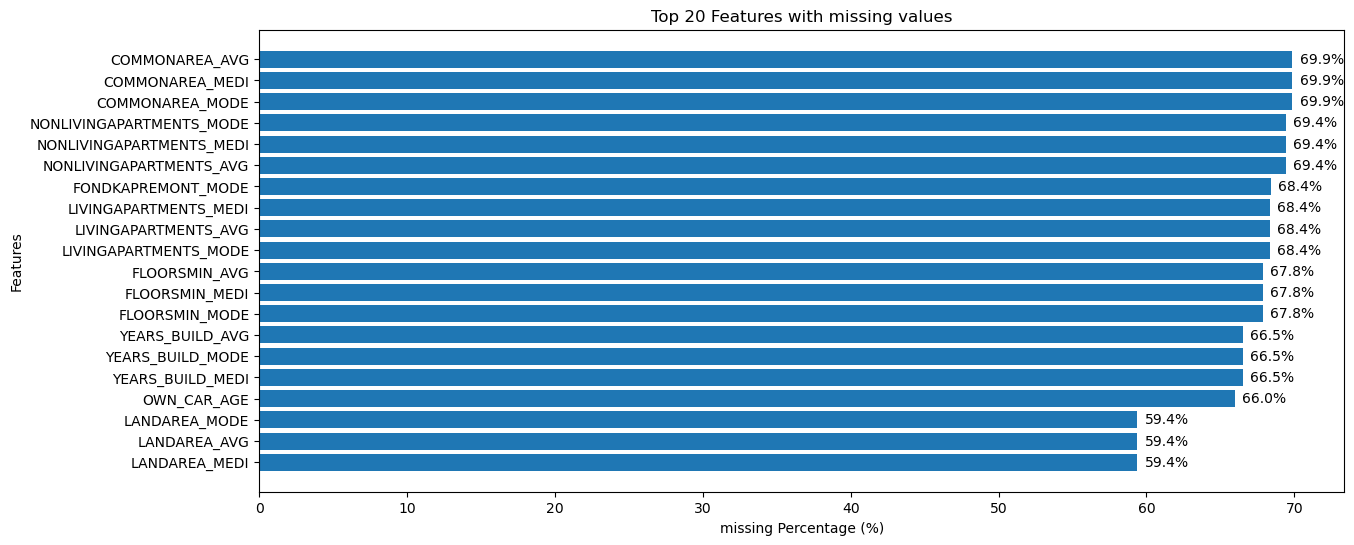

In [15]:
top20 = missing_data.iloc[:20][::-1]

plt.figure(figsize=(14,6))
# plt.subplot(1,2,1)
bars = plt.barh(top20.index, top20['missing_percentage'])

plt.title('Top 20 Features with missing values')
plt.xlabel('missing Percentage (%)')
plt.ylabel('Features')


for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', ha='left', va='center')




Top 20 column wise missing data 

In [16]:
cols_to_drop = missing_data[
    (missing_data['missing_percentage'] >= 60) &
    (missing_data['missing_percentage'] <= 100)
].index

application_train = application_train.drop(columns=cols_to_drop)


In [17]:
# this columns has been drop due to missing value\''''''''''''''''''''''''

cols_to_drop

Index(['COMMONAREA_AVG', 'COMMONAREA_MEDI', 'COMMONAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_AVG', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MODE', 'FLOORSMIN_AVG', 'FLOORSMIN_MEDI', 'FLOORSMIN_MODE', 'YEARS_BUILD_AVG', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'OWN_CAR_AGE'], dtype='object')

In [18]:

# application_train['COMMONAREA_MODE']
# application_train['YEARS_BUILD_AVG']

In [19]:


application_train['CREDIT_INCOME_RATIO'] = application_train['AMT_CREDIT'] / application_train['AMT_INCOME_TOTAL']

application_train['ANNUITY_INCOME_RATIO'] = application_train['AMT_ANNUITY']/ application_train['AMT_INCOME_TOTAL']

application_train['CREDIT_TERM'] = application_train['AMT_CREDIT'] / application_train['AMT_GOODS_PRICE']

number of loans user currently has

### Bureau

In [20]:
bureau.head(5)

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [21]:
burea_agg = bureau.groupby('SK_ID_CURR').agg({
    'SK_ID_BUREAU':'count',       #how many previous loan
    'AMT_CREDIT_SUM':'sum',       # total credit limit somewhere
    'AMT_CREDIT_SUM_DEBT':'sum',  # total curr debt somewhere
    'CREDIT_ACTIVE': lambda x: (x == 'Active').sum() # count of active loans
})
# renaming previous created column
burea_agg.columns = ['BUREAU_LOAN_COUNT', 'BUREAU_TOTAL_CREDIT', 'BUREAU_TOTAL_DEBT', 'BUREAU_ACTIVE_LOANS']

burea_agg.reset_index(inplace=True)

In [22]:
burea_agg.isnull().sum()

SK_ID_CURR             0
BUREAU_LOAN_COUNT      0
BUREAU_TOTAL_CREDIT    0
BUREAU_TOTAL_DEBT      0
BUREAU_ACTIVE_LOANS    0
dtype: int64

In [23]:
# merging with application_data

application_train = application_train.merge(burea_agg, on='SK_ID_CURR', how='left')

In [24]:
# filling new NaN values created by merge , replace by 0

cols_to_fill = ['BUREAU_LOAN_COUNT', 'BUREAU_TOTAL_CREDIT', 'BUREAU_TOTAL_DEBT', 'BUREAU_ACTIVE_LOANS']

application_train[cols_to_fill] = application_train[cols_to_fill].fillna(0)

### Visulization

### Univariate : Target Variable

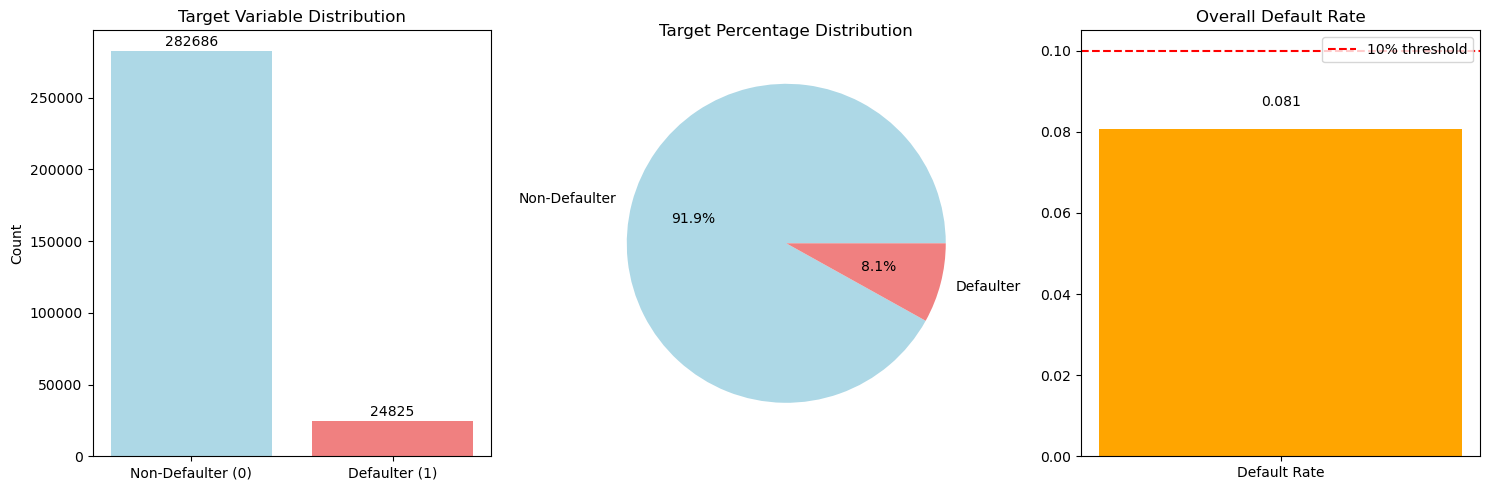

Default Rate: 0.0807 (8.07%)
Class Imbalance Ratio: 11.39:1


In [25]:
# Target distribution analysis
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
target_counts = application_train['TARGET'].value_counts()
plt.bar(['Non-Defaulter (0)', 'Defaulter (1)'], target_counts.values, color=['lightblue', 'lightcoral'])
plt.title('Target Variable Distribution')
plt.ylabel('Count')
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 1000, str(v), ha='center', va='bottom')

plt.subplot(1, 3, 2)
plt.pie(target_counts.values, labels=['Non-Defaulter', 'Defaulter'], autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Target Percentage Distribution')

plt.subplot(1, 3, 3)
default_rate = application_train['TARGET'].mean()
plt.bar(['Default Rate'], [default_rate], color='orange')
plt.axhline(y=0.1, color='red', linestyle='--', label='10% threshold')
plt.text(0, default_rate + 0.005, f'{default_rate:.3f}', ha='center', va='bottom')
plt.legend()
plt.title('Overall Default Rate')

plt.tight_layout()
plt.show()

print(f"Default Rate: {default_rate:.4f} ({default_rate*100:.2f}%)")
print(f"Class Imbalance Ratio: {target_counts[0]/target_counts[1]:.2f}:1")

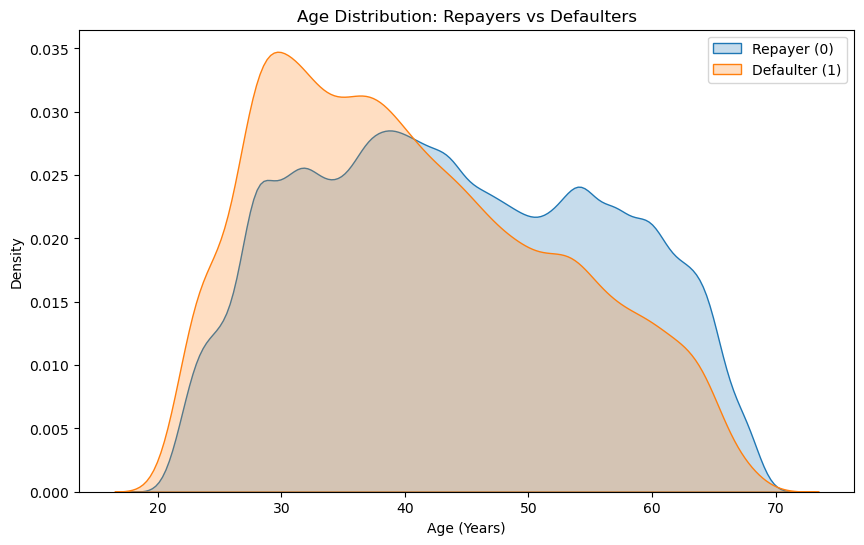

In [26]:

plt.figure(figsize=(10,6))
sns.kdeplot(application_train.loc[application_train['TARGET'] == 0, 'AGE_YEARS'], label='Repayer (0)', shade=True)
sns.kdeplot(application_train.loc[application_train['TARGET'] == 1, 'AGE_YEARS'], label='Defaulter (1)', shade=True)
plt.title('Age Distribution: Repayers vs Defaulters')
plt.xlabel('Age (Years)')
plt.legend()
plt.show()


* Younger applicants (20 ~ 30) have a higher density in the defaulter category

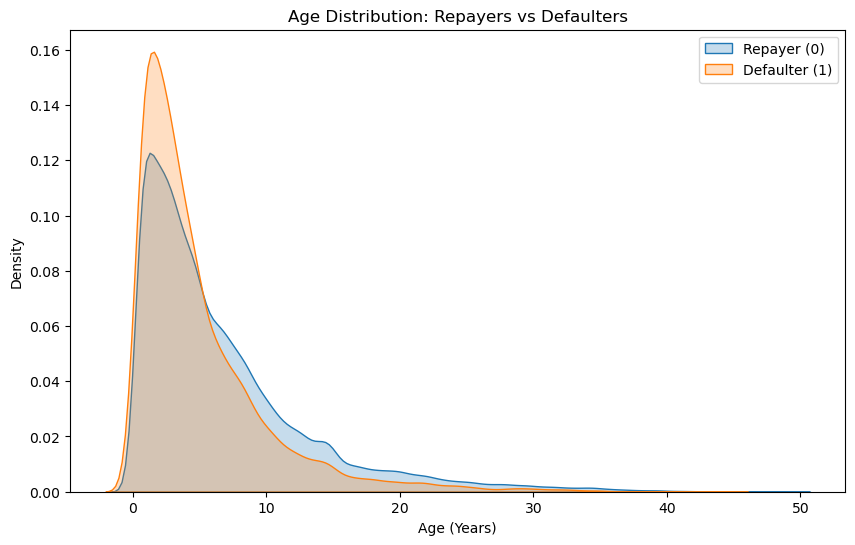

In [29]:

plt.figure(figsize=(10,6))
sns.kdeplot(application_train.loc[application_train['TARGET'] == 0, 'YEAR_EMPLOYED'], label='Repayer (0)', shade=True)
sns.kdeplot(application_train.loc[application_train['TARGET'] == 1, 'YEAR_EMPLOYED'], label='Defaulter (1)', shade=True)
plt.title('Age Distribution: Repayers vs Defaulters')
plt.xlabel('Age (Years)')
plt.legend()
plt.show()


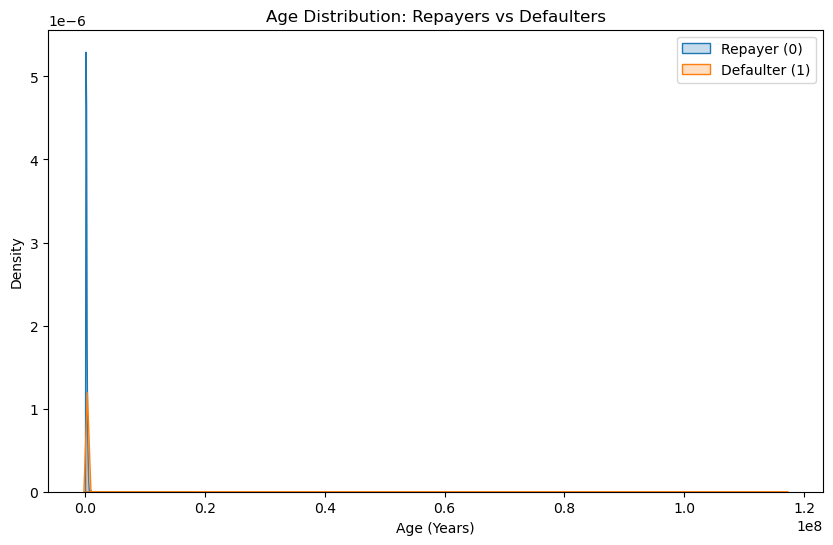

In [30]:

plt.figure(figsize=(10,6))
sns.kdeplot(application_train.loc[application_train['TARGET'] == 0, 'AMT_INCOME_TOTAL'], label='Repayer (0)', shade=True)
sns.kdeplot(application_train.loc[application_train['TARGET'] == 1, 'AMT_INCOME_TOTAL'], label='Defaulter (1)', shade=True)
plt.title('Age Distribution: Repayers vs Defaulters')
plt.xlabel('Age (Years)')
plt.legend()
plt.show()


so this has outlier and need to remove outlier

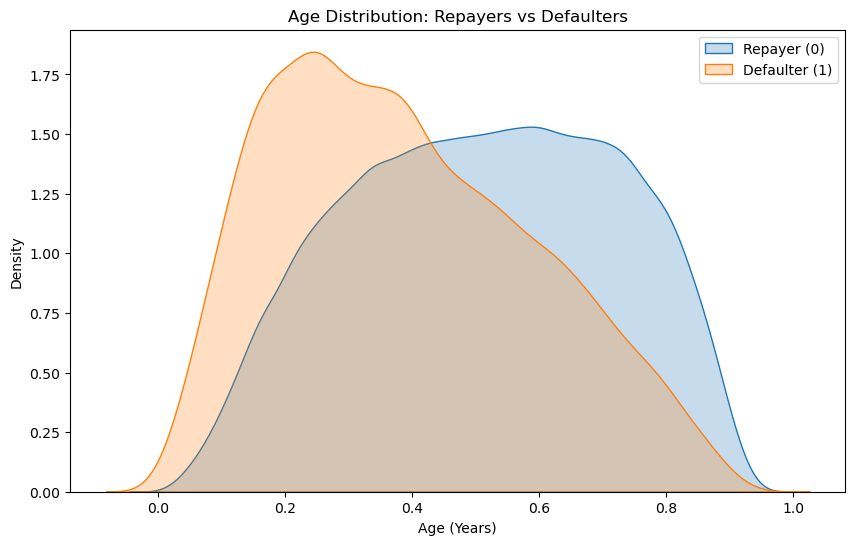

In [31]:

plt.figure(figsize=(10,6))
sns.kdeplot(application_train.loc[application_train['TARGET'] == 0, 'EXT_SOURCE_1'], label='Repayer (0)', shade=True)
sns.kdeplot(application_train.loc[application_train['TARGET'] == 1, 'EXT_SOURCE_1'], label='Defaulter (1)', shade=True)
plt.title('Age Distribution: Repayers vs Defaulters')
plt.xlabel('Age (Years)')
plt.legend()
plt.show()


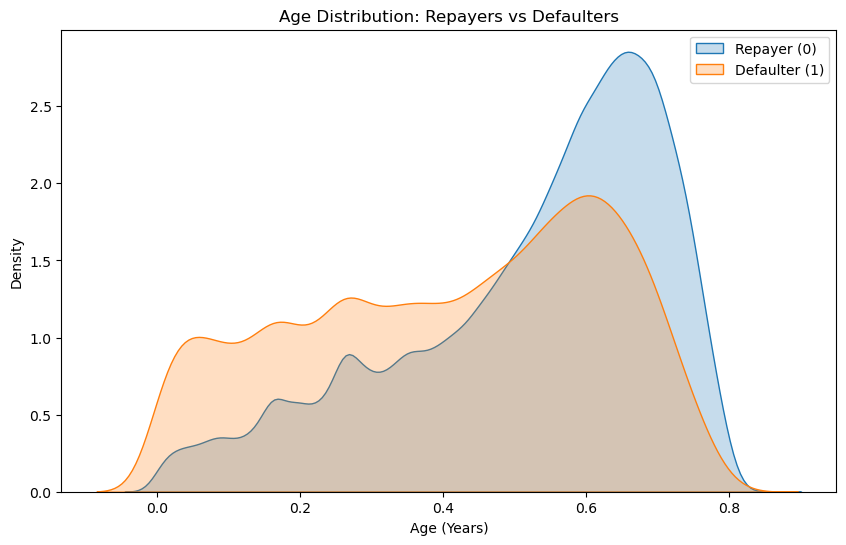

In [51]:

plt.figure(figsize=(10,6))
sns.kdeplot(application_train.loc[application_train['TARGET'] == 0, 'EXT_SOURCE_2'], label='Repayer (0)', shade=True)
sns.kdeplot(application_train.loc[application_train['TARGET'] == 1, 'EXT_SOURCE_2'], label='Defaulter (1)', shade=True)
plt.title('Age Distribution: Repayers vs Defaulters')
plt.xlabel('Age (Years)')
plt.legend()
plt.show()


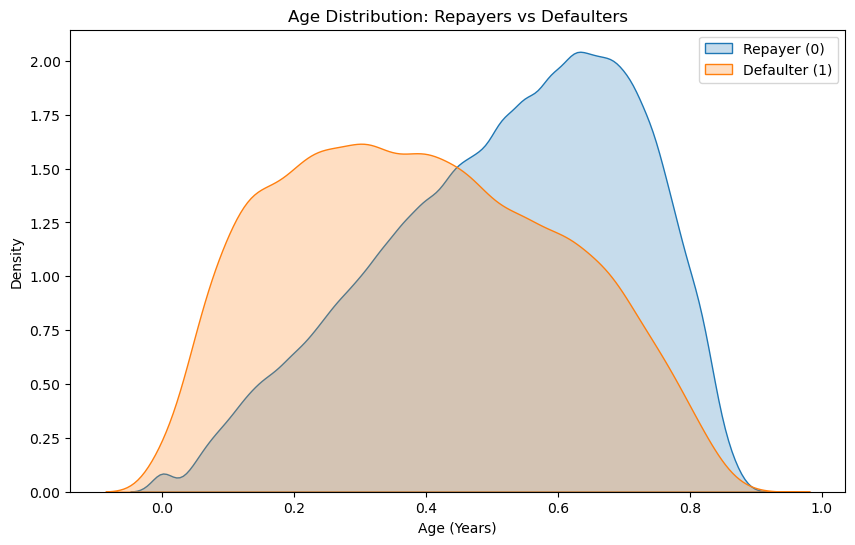

In [52]:

plt.figure(figsize=(10,6))
sns.kdeplot(application_train.loc[application_train['TARGET'] == 0, 'EXT_SOURCE_3'], label='Repayer (0)', shade=True)
sns.kdeplot(application_train.loc[application_train['TARGET'] == 1, 'EXT_SOURCE_3'], label='Defaulter (1)', shade=True)
plt.title('Age Distribution: Repayers vs Defaulters')
plt.xlabel('Age (Years)')
plt.legend()
plt.show()


In [56]:

# plt.figure(figsize=(10,6))
# sns.kdeplot(app_train_final.loc[app_train_final['TARGET'] == 0, 'CREDIT_ACTIVE'], label='Repayer (0)', shade=True)
# sns.kdeplot(app_train_final.loc[app_train_final['TARGET'] == 1, 'CREDIT_ACTIVE'], label='Defaulter (1)', shade=True)
# plt.title('Age Distribution: Repayers vs Defaulters')
# plt.xlabel('Age (Years)')
# plt.legend()
# plt.show()


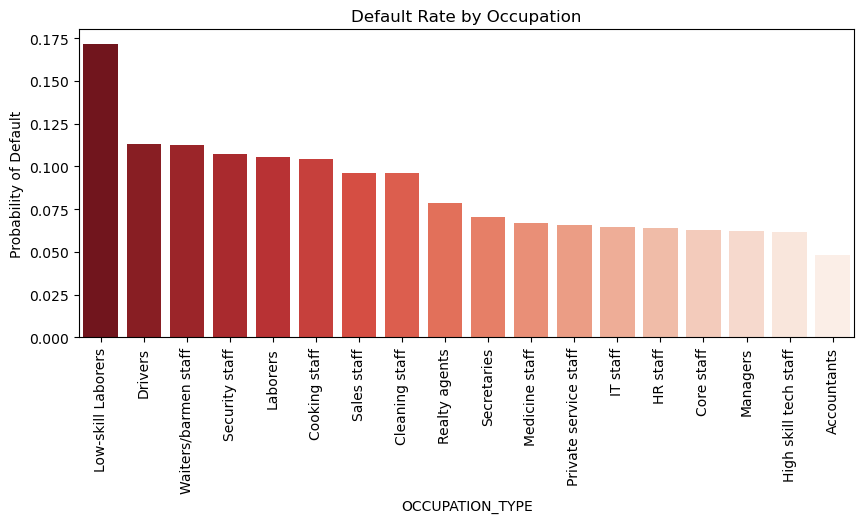

In [61]:
plt.figure(figsize=(10,4))
# Calculate default rate by occupation
occ_group = application_train.groupby('OCCUPATION_TYPE')['TARGET'].mean().sort_values(ascending=False)
sns.barplot(x=occ_group.index, y=occ_group.values, palette='Reds_r')
plt.xticks(rotation=90)
plt.title('Default Rate by Occupation')
plt.ylabel('Probability of Default')
plt.show()


INSIGHT: The riskiest profession is Low-skill Laborers, while the safest is Accountants.

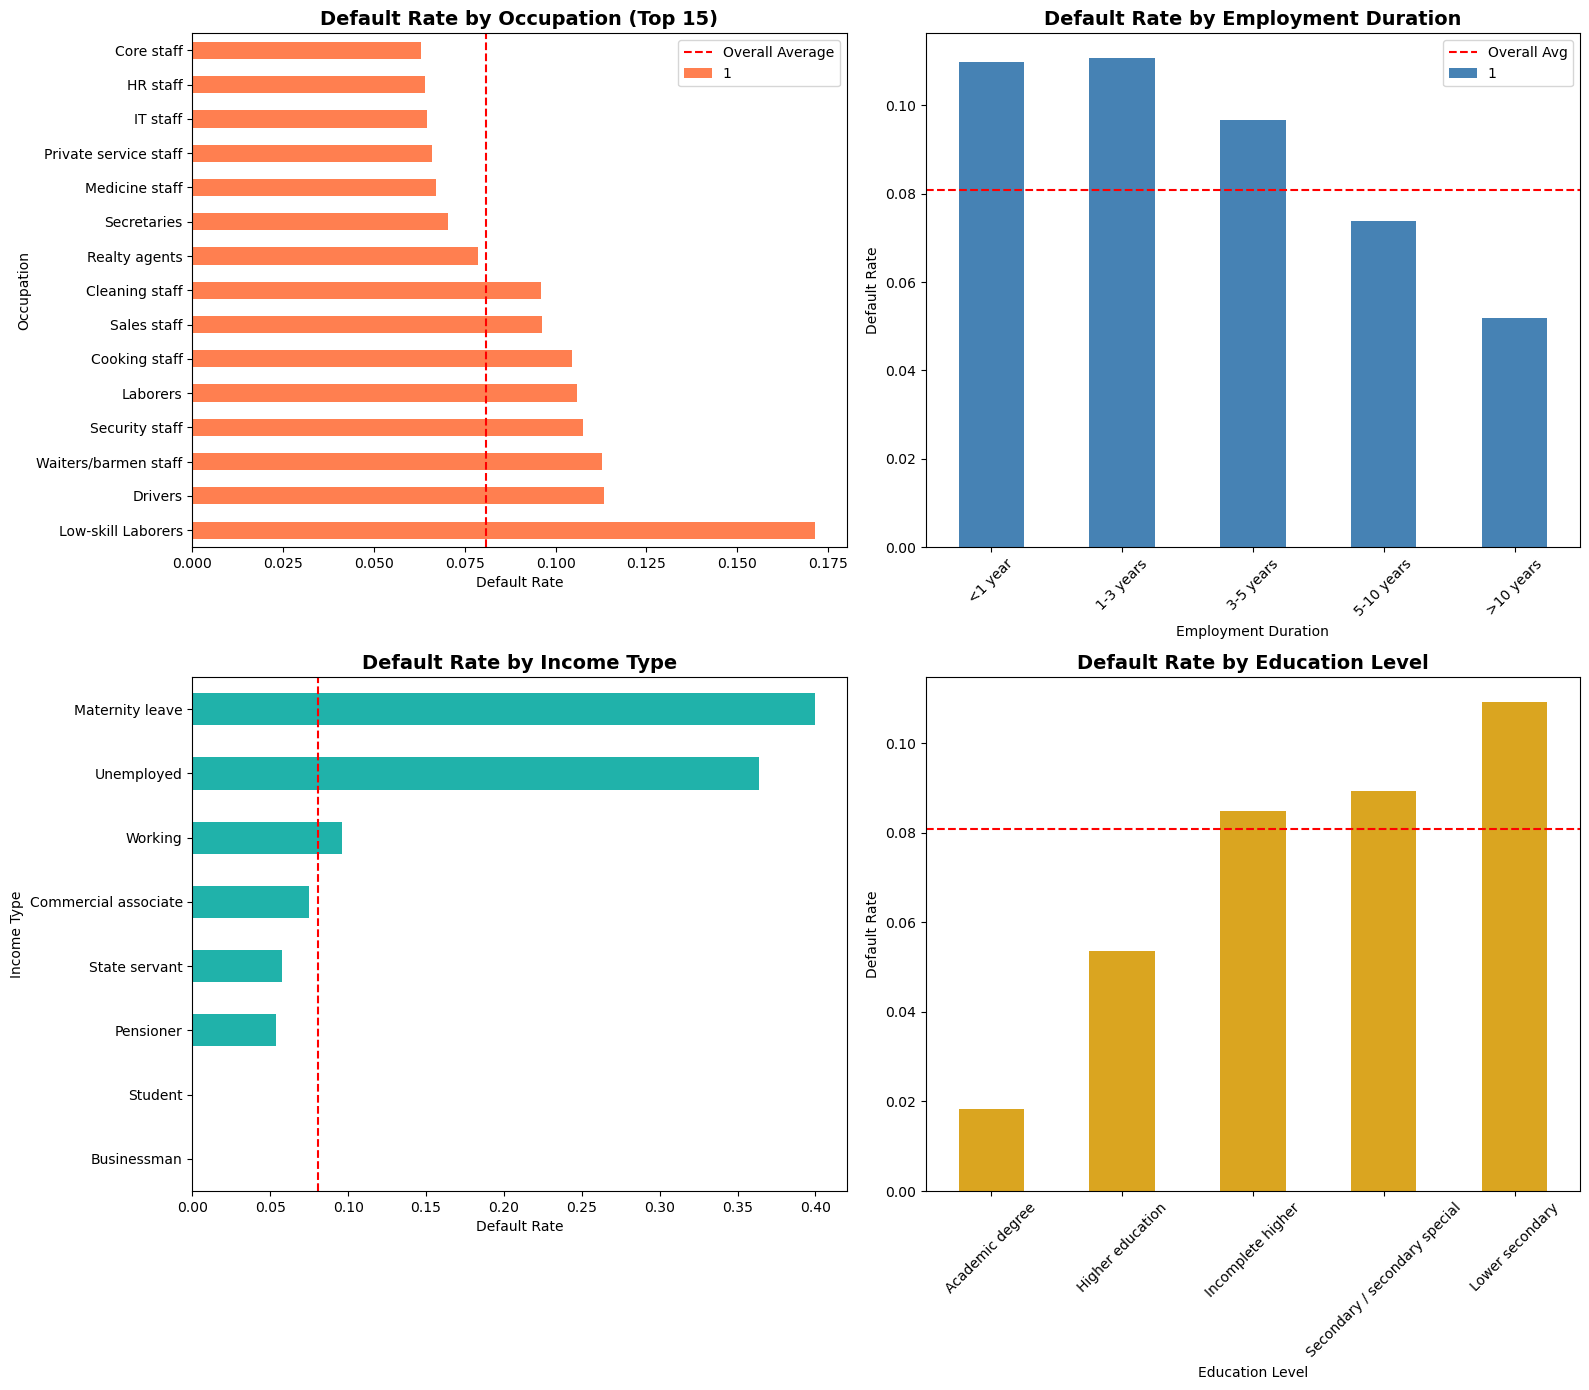

In [33]:
# Occupation analysis
plt.figure(figsize=(16, 14))

# Default rate by occupation (top 15)
plt.subplot(2, 2, 1)
occupation_default = pd.crosstab(application_train['OCCUPATION_TYPE'], application_train['TARGET'], normalize='index')
occupation_default = occupation_default.sort_values(by=1, ascending=False).head(15)
occupation_default[1].plot(kind='barh', color='coral')
plt.title('Default Rate by Occupation (Top 15)', fontsize=14, fontweight='bold')
plt.xlabel('Default Rate')
plt.ylabel('Occupation')
plt.axvline(x=application_train['TARGET'].mean(), color='red', linestyle='--', label='Overall Average')
plt.legend()

# Employment years vs default
plt.subplot(2, 2, 2)
application_train['EMPLOYMENT_CATEGORY'] = pd.cut(application_train['YEAR_EMPLOYED'], 
                                         bins=[-1, 1, 3, 5, 10, 50],
                                         labels=['<1 year', '1-3 years', '3-5 years', 
                                                 '5-10 years', '>10 years'])
emp_default = pd.crosstab(application_train['EMPLOYMENT_CATEGORY'], application_train['TARGET'], normalize='index')
emp_default[1].plot(kind='bar', color='steelblue')
plt.title('Default Rate by Employment Duration', fontsize=14, fontweight='bold')
plt.xlabel('Employment Duration')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.axhline(y=application_train['TARGET'].mean(), color='red', linestyle='--', label='Overall Avg')
plt.legend()

# Income type analysis
plt.subplot(2, 2, 3)
income_type_default = pd.crosstab(application_train['NAME_INCOME_TYPE'], application_train['TARGET'], normalize='index')
income_type_default = income_type_default.sort_values(by=1, ascending=True)
income_type_default[1].plot(kind='barh', color='lightseagreen')
plt.title('Default Rate by Income Type', fontsize=14, fontweight='bold')
plt.xlabel('Default Rate')
plt.ylabel('Income Type')
plt.axvline(x=application_train['TARGET'].mean(), color='red', linestyle='--')

# Education level analysis
plt.subplot(2, 2, 4)
education_default = pd.crosstab(application_train['NAME_EDUCATION_TYPE'], application_train['TARGET'], normalize='index')
education_default = education_default.sort_values(by=1, ascending=True)
education_default[1].plot(kind='bar', color='goldenrod')
plt.title('Default Rate by Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Education Level')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.axhline(y=application_train['TARGET'].mean(), color='red', linestyle='--')

plt.tight_layout()
plt.show()



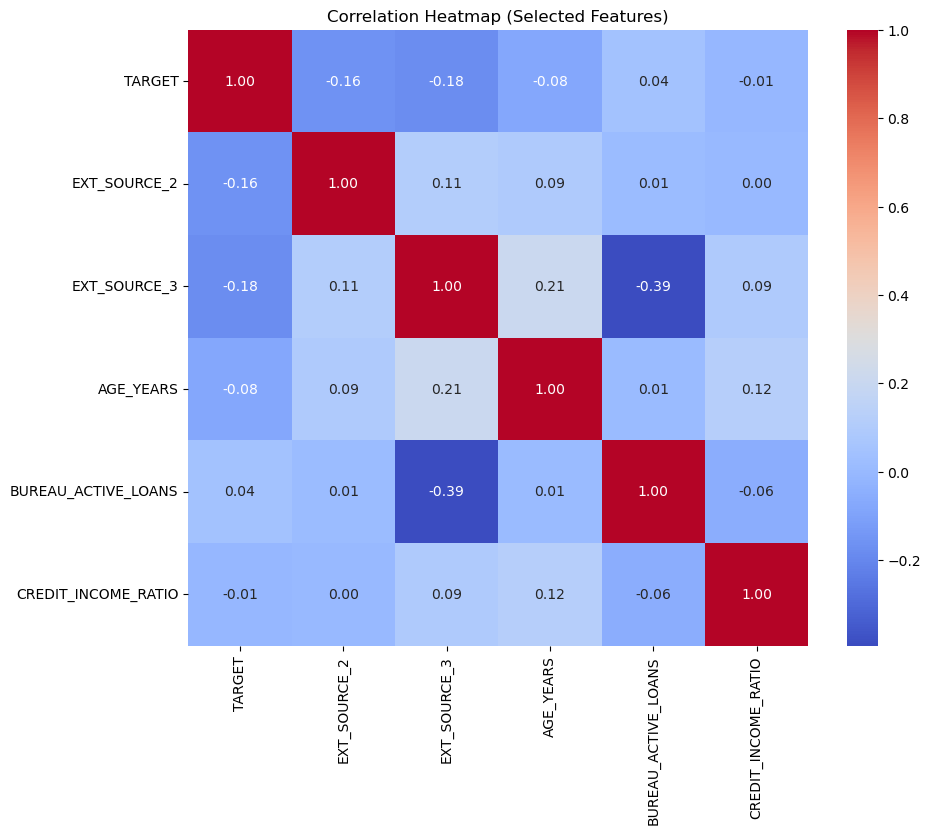

In [34]:
# External Sources Correlation
# EXT_SOURCE columns are scores from external agencies. Let's see their impact.
ext_cols = ['TARGET', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE_YEARS', 'BUREAU_ACTIVE_LOANS', 'CREDIT_INCOME_RATIO']
corr_matrix = application_train[ext_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Selected Features)')
plt.show()

## Feature Engineering

In [35]:
# CAtegorical FEature

categorical_col = application_train.select_dtypes(include=['object']).columns.tolist()
print(f'Number of categorical columns: {len(categorical_col)}')

Number of categorical columns: 15


In [36]:
# important key categorical feature

key_categorical = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_INCOME_TYPE', 
                   'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
                   'OCCUPATION_TYPE']

In [37]:
# Numerical Feature

numerical_col = application_train.select_dtypes(include=[np.number]).columns.to_list()
print(f'Number of Numerical COlumns: {len(numerical_col)}')

Number of Numerical COlumns: 97


In [38]:
# important key numerical feature

key_numerical = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
                 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'CREDIT_INCOME_RATIO','ANNUITY_INCOME_RATIO',
                'AGE_YEARS','YEAR_EMPLOYED']

In [39]:
key_numerical

['AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'CNT_CHILDREN',
 'CNT_FAM_MEMBERS',
 'CREDIT_INCOME_RATIO',
 'ANNUITY_INCOME_RATIO',
 'AGE_YEARS',
 'YEAR_EMPLOYED']

### Numerical column [ handling outlier and filling NaN values ] 

In [40]:
# analyze each key numerical feature
# using for loop to handle nan in one step in column wise in key_numerical variable

for col in key_numerical:
    if col in application_train.columns:
        print(f'\n {col}:')
        print(f'Missing values: {application_train[col].isnull().sum():} ({application_train[col].isnull().mean()*100:.2f}%) ')


        # checking OUtlier
        Q1 = application_train[col].quantile(0.25)
        Q3 = application_train[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bond = Q1 - 1.5 * IQR
        upper_bond = Q3 + 1.5 * IQR
        outliers = ((application_train[col] < lower_bond) | (application_train[col] > upper_bond)).sum()

        print(f'Outlier (IQR Method): {outliers:,} ({outliers/len(application_train)*100:.2f})')
        


 AMT_INCOME_TOTAL:
Missing values: 0 (0.00%) 
Outlier (IQR Method): 14,035 (4.56)

 AMT_CREDIT:
Missing values: 0 (0.00%) 
Outlier (IQR Method): 6,562 (2.13)

 AMT_ANNUITY:
Missing values: 12 (0.00%) 
Outlier (IQR Method): 7,504 (2.44)

 AMT_GOODS_PRICE:
Missing values: 278 (0.09%) 
Outlier (IQR Method): 14,728 (4.79)

 CNT_CHILDREN:
Missing values: 0 (0.00%) 
Outlier (IQR Method): 4,272 (1.39)

 CNT_FAM_MEMBERS:
Missing values: 2 (0.00%) 
Outlier (IQR Method): 4,007 (1.30)

 CREDIT_INCOME_RATIO:
Missing values: 0 (0.00%) 
Outlier (IQR Method): 11,510 (3.74)

 ANNUITY_INCOME_RATIO:
Missing values: 12 (0.00%) 
Outlier (IQR Method): 7,878 (2.56)

 AGE_YEARS:
Missing values: 0 (0.00%) 
Outlier (IQR Method): 0 (0.00)

 YEAR_EMPLOYED:
Missing values: 55374 (18.01%) 
Outlier (IQR Method): 15,149 (4.93)


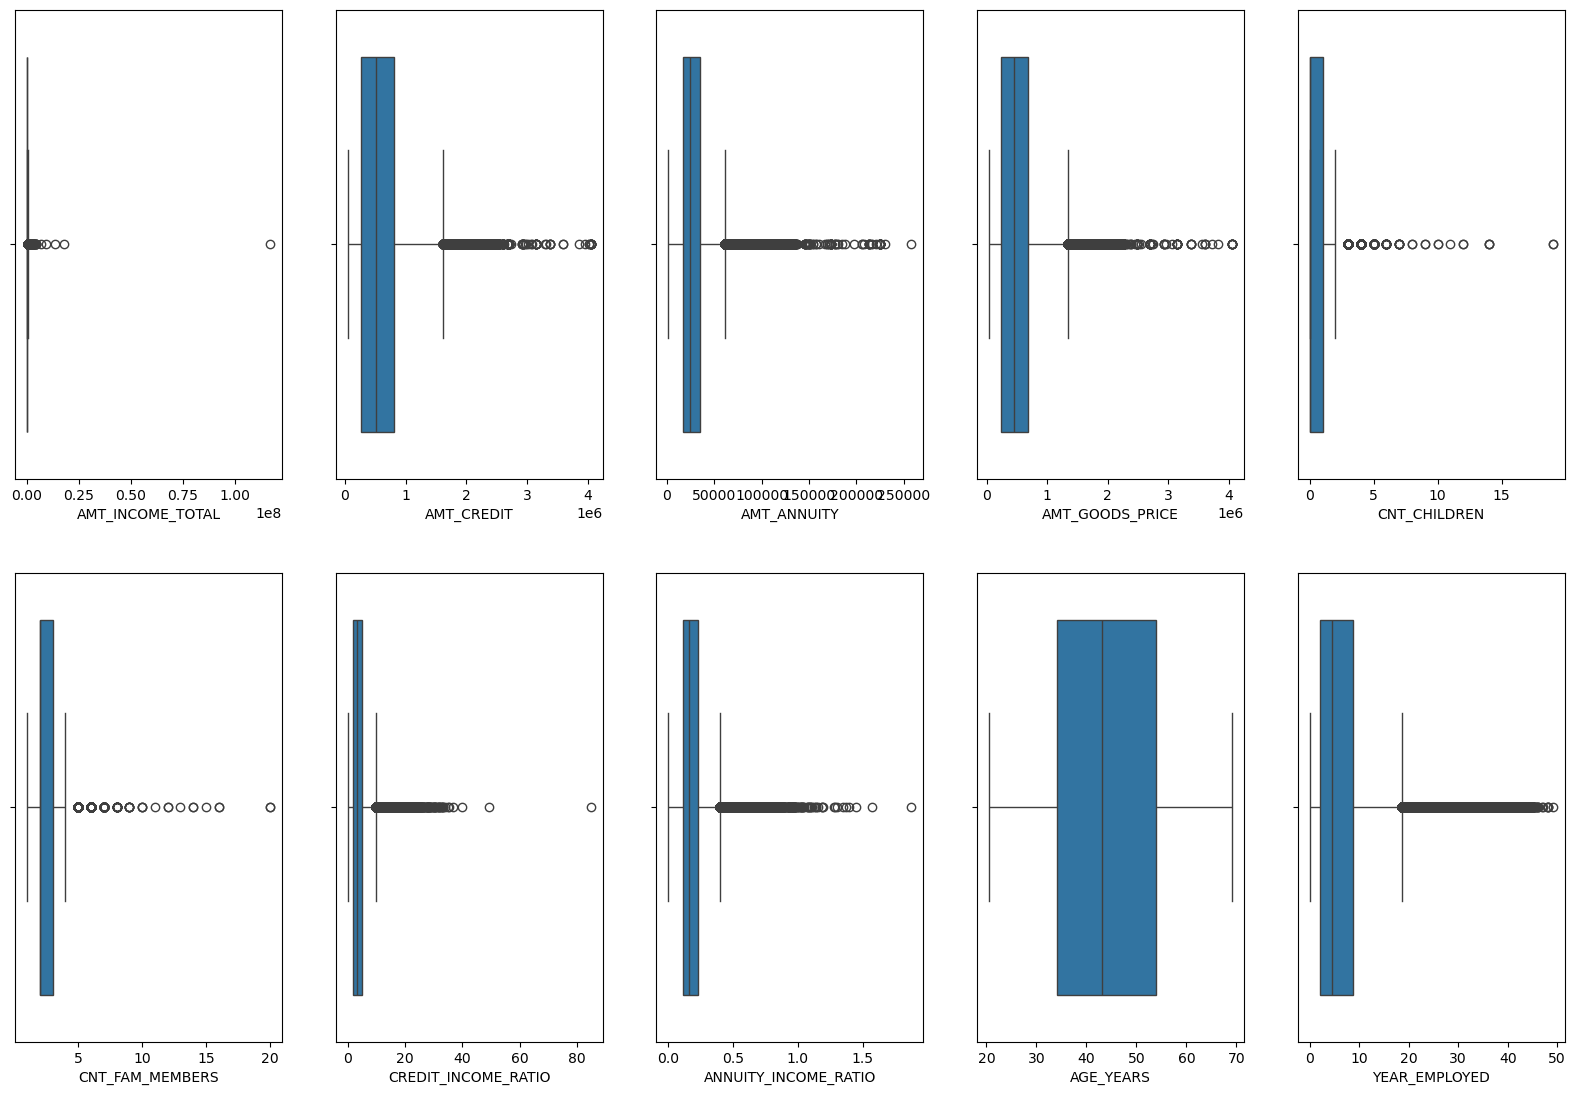

In [41]:
plt.figure(figsize=(20, 145))

for i, col in enumerate(key_numerical):
    plt.subplot(20, 5, i + 1)
    sns.boxplot(x=application_train[col])
    # plt.title(col)

This is before capping outlier

In [42]:
# plt.figure(figsize=(18,4))
# sns.boxplot(x = application_train['AMT_CREDIT'])

In [43]:
app_train_capped = application_train.copy()

for col in ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'CREDIT_INCOME_RATIO','ANNUITY_INCOME_RATIO']:
    if col in app_train_capped.columns:
        lower_limit = app_train_capped[col].quantile(0.01)
        upper_limit = app_train_capped[col].quantile(0.99)
        
        app_train_capped[col] = np.where(app_train_capped[col] < lower_limit, lower_limit,
                                    np.where(app_train_capped[col] > upper_limit, upper_limit, 
                                    app_train_capped[col]))
        

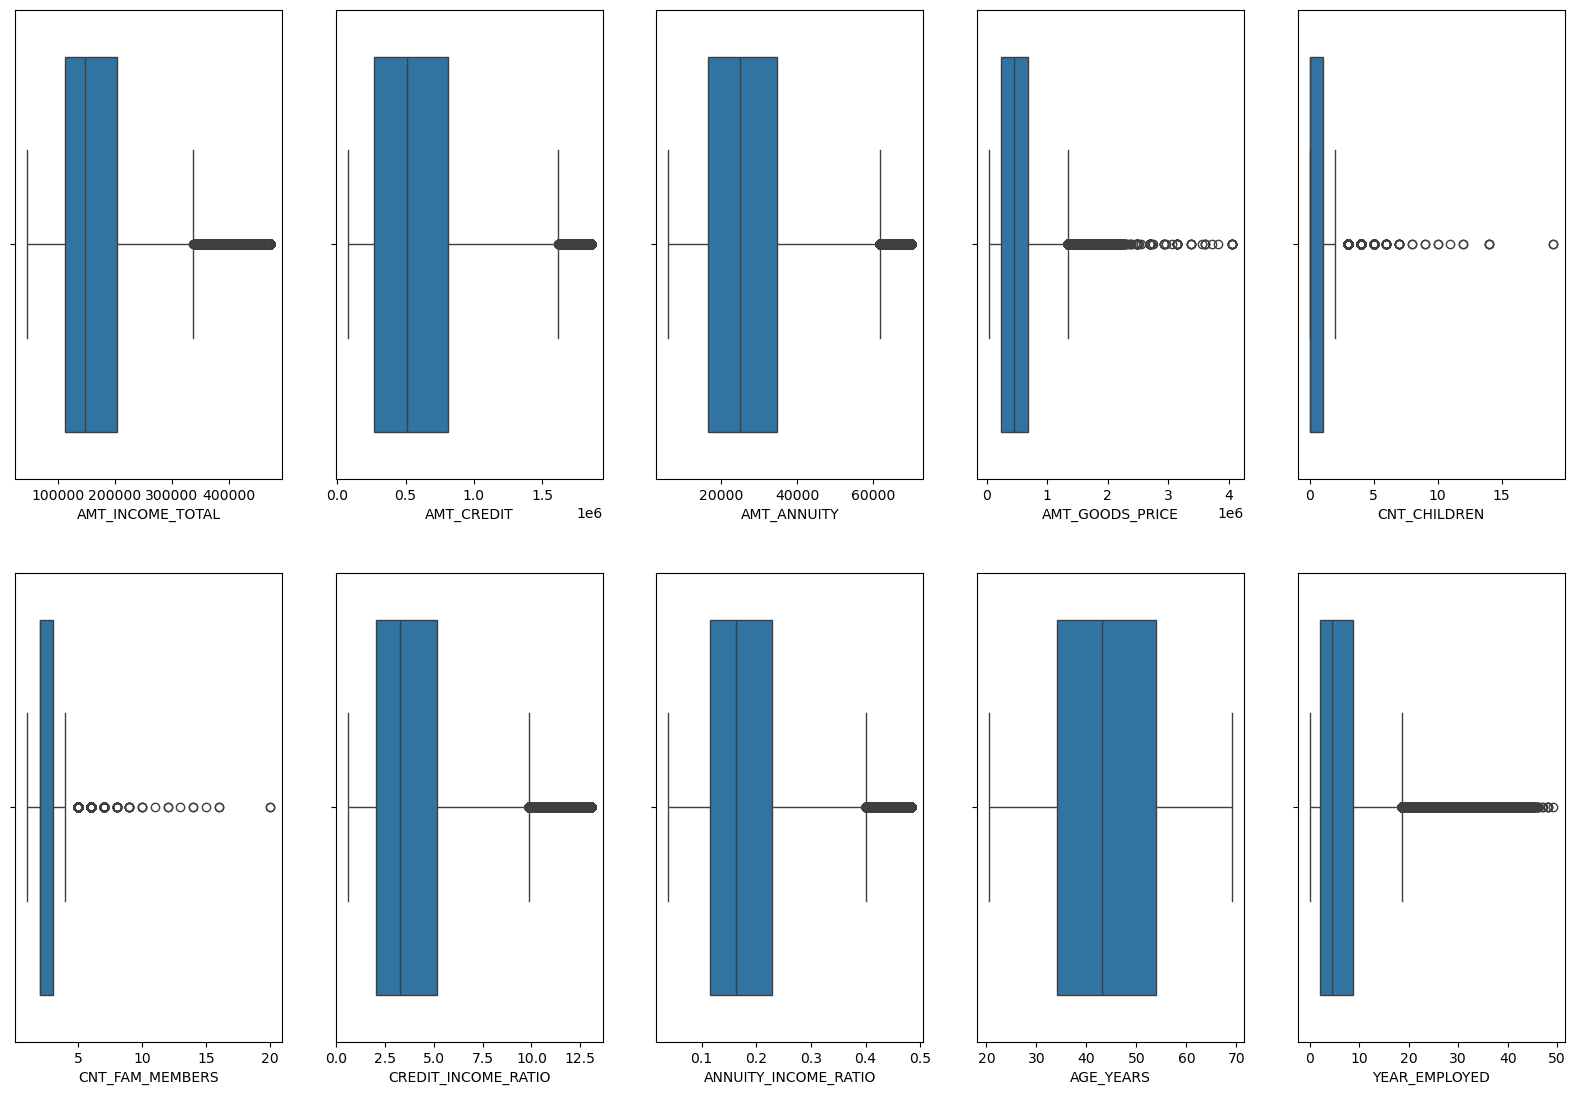

In [44]:
plt.figure(figsize=(20, 145))

for i, col in enumerate(key_numerical):
    plt.subplot(20, 5, i + 1)
    sns.boxplot(x=app_train_capped[col])
    # plt.title(col)

This is after capping outlier

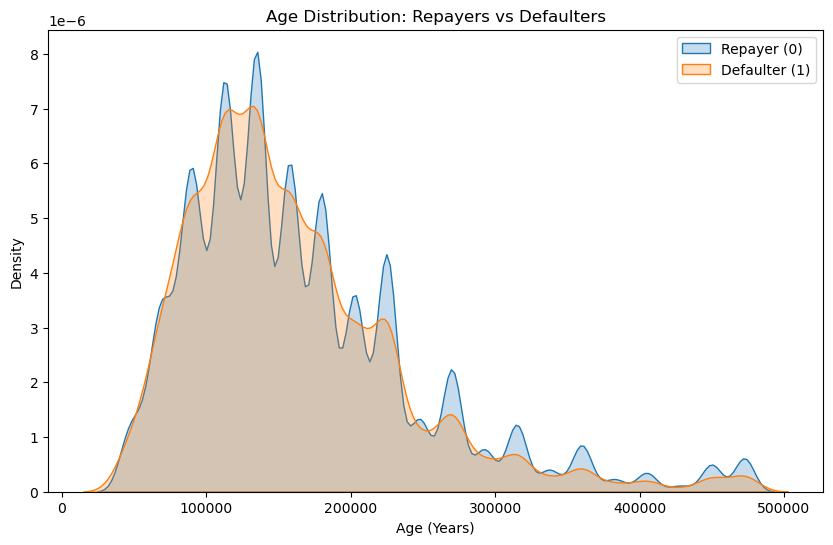

In [50]:

plt.figure(figsize=(10,6))
sns.kdeplot(app_train_capped.loc[app_train_capped['TARGET'] == 0, 'AMT_INCOME_TOTAL'], label='Repayer (0)', shade=True)
sns.kdeplot(app_train_capped.loc[app_train_capped['TARGET'] == 1, 'AMT_INCOME_TOTAL'], label='Defaulter (1)', shade=True)
plt.title('Age Distribution: Repayers vs Defaulters')
plt.xlabel('Age (Years)')
plt.legend()
plt.show()


Now we can revisit the total income feature after removing outliers and we see the minor differences in distributions when loans are repaid or defaulted.

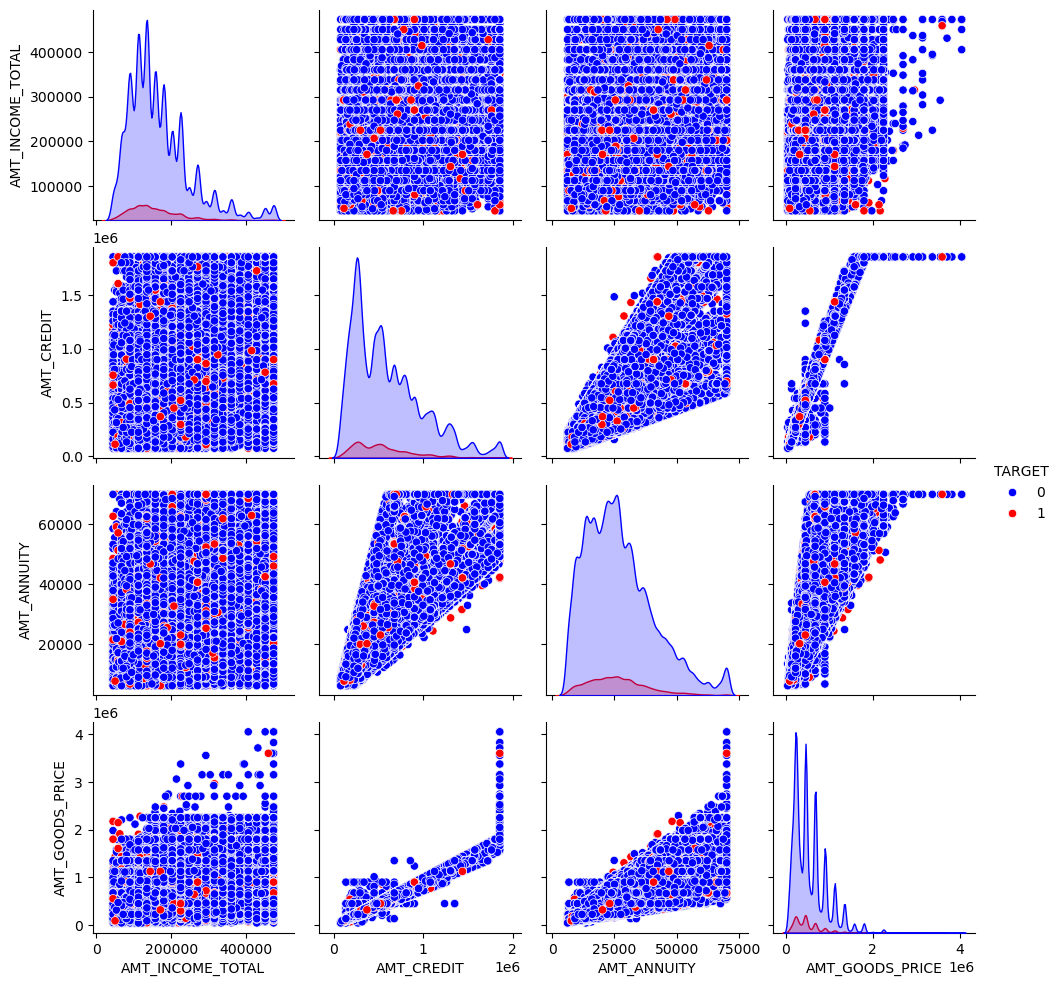

In [53]:
amt = app_train_capped[[ 'AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY', 'AMT_GOODS_PRICE',"TARGET"]]
amt = amt[(amt["AMT_GOODS_PRICE"].notnull()) & (amt["AMT_ANNUITY"].notnull())]
g = sns.pairplot(amt,hue="TARGET",palette=["b","r"])  

plt.show()

In [45]:
# filling missing value with median

numerical_col = app_train_capped.select_dtypes(include=['int64','float64']).columns

for col in numerical_col:
    app_train_capped[col].fillna(app_train_capped[col].median(), inplace=True)


### Categorical column [ filling NaN values and applying one hot encoding] 

In [46]:
app_train_final = app_train_capped.copy()

categorical_col = app_train_final.select_dtypes(include=['object']).columns

for col in categorical_col:
    app_train_final[col].fillna(app_train_final[col].mode()[0], inplace=True)

In [47]:
# do one-hot encoding

app_train_final = pd.get_dummies(app_train_final, drop_first=True)

In [48]:
# app_train_final.isnull().sum()

app_train_final.head(2)

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,LANDAREA_AVG,LIVINGAREA_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,LANDAREA_MODE,LIVINGAREA_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,LANDAREA_MEDI,LIVINGAREA_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,YEAR_EMPLOYED,YEAR_REGISTRATION,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_TERM,BUREAU_LOAN_COUNT,BUREAU_TOTAL_CREDIT,BUREAU_TOTAL_DEBT,BUREAU_ACTIVE_LOANS,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_M,CODE_GENDER_XNA,FLAG_OWN_CAR_Y,FLAG_OWN_REALTY_Y,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Maternity leave,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Unknown,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Agriculture,ORGANIZATION_TYPE_Bank,ORGANIZATION_TYPE_Business Entity Type 1,ORGANIZATION_TYPE_Business Entity Type 2,ORGANIZATION_TYPE_Business Entity Type 3,ORGANIZATION_TYPE_Cleaning,ORGANIZATION_TYPE_Construction,ORGANIZATION_TYPE_Culture,ORGANIZATION_TYPE_Electricity,ORGANIZATION_TYPE_Emergency,ORGANIZATION_TYPE_Government,ORGANIZATION_TYPE_Hotel,ORGANIZATION_TYPE_Housing,ORGANIZATION_TYPE_Industry: type 1,ORGANIZATION_TYPE_Industry: type 10,ORGANIZATION_TYPE_Industry: type 11,ORGANIZATION_TYPE_Industry: type 12,ORGANIZATION_TYPE_Industry: ty

In [62]:
app_train_final.drop(['CODE_GENDER_XNA','ORGANIZATION_TYPE_XNA'], axis=1, inplace=True)

Correlation with target

In [63]:
corr_data = application_train[key_numerical + ['TARGET']].corr()

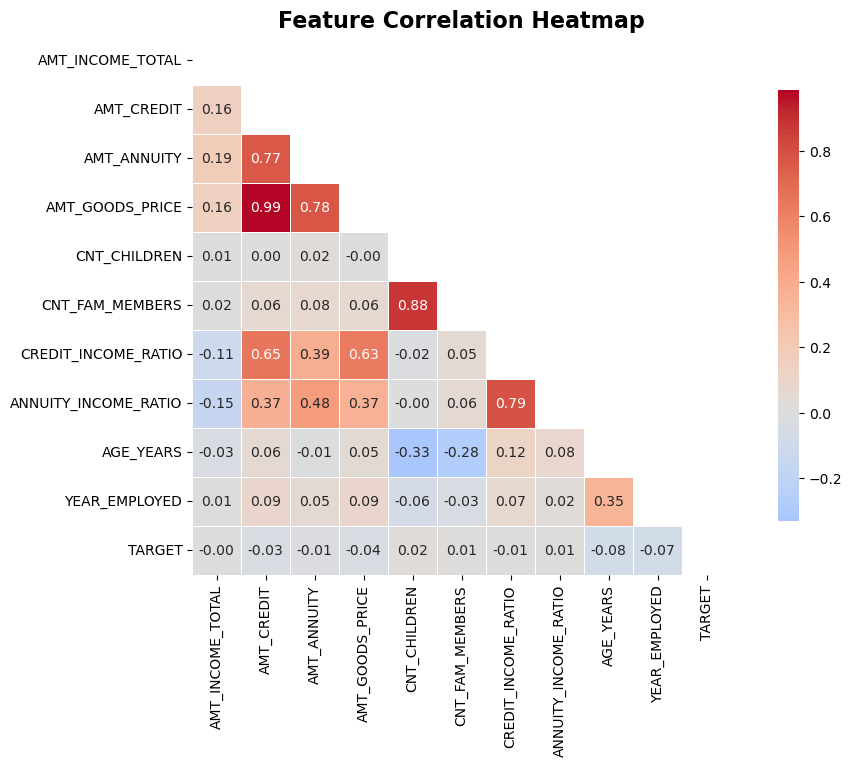

In [64]:
plt.figure(figsize=(12,7))

mask = np.triu(np.ones_like(corr_data, dtype=bool))

sns.heatmap(corr_data, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')

plt.show()

### Risk Management

In [65]:



# calcaluate risk score

def calculate_risk_score(row):
    score = 0


    # Age risk (young = higher risk)
    if row['AGE_YEARS'] < 25:
        score +=  3
    elif row['AGE_YEARS'] < 35:
        score += 2
    elif row['AGE_YEARS'] < 45:
        score += 1


    # Income risk
    if row['AMT_INCOME_TOTAL'] < 50000:
        score += 3
    elif row['AMT_INCOME_TOTAL'] < 100000:
        score += 2
    elif row['AMT_INCOME_TOTAL'] < 150000:
        score += 1


    # Loan-to-income risk
    if row['CREDIT_INCOME_RATIO'] > 0.2:
        score += 3
    elif row['CREDIT_INCOME_RATIO'] > 0.11:
        score += 2
    elif row['CREDIT_INCOME_RATIO'] > 0.05:
        score += 1


    # Employement risk 
    if pd.isna(row.get('YEAR_EMPLOYED', np.nan)):
        score += 3  # Unemployed or anomaly
    elif row.get('YEAR_EMPLOYED', 0) < 1:
        score += 2
    elif row.get('YEAR_EMPLOYED', 0) < 3:
        score += 1
    
    return score


In [66]:
# Calculate risk scores
app_train_final['RISK_SCORE'] = app_train_final.apply(calculate_risk_score, axis=1)



# Categorize risk levels
app_train_final['RISK_CATEGORY'] = pd.cut(app_train_final['RISK_SCORE'], 
                                               bins=[-1, 3, 6, 9, 20],
                                               labels=['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk'])

# Analyze risk categories
print("\nRisk Segmentation Analysis:\n")
risk_summary = app_train_final.groupby('RISK_CATEGORY').agg({
    'TARGET': ['count', 'mean'],
    'AMT_INCOME_TOTAL': 'median',
    'AGE_YEARS': 'median',
    'CREDIT_INCOME_RATIO': 'median'
}).round(3)

risk_summary.columns = ['Count', 'Default Rate', 'Median Income', 'Median Age', 'Median LTI']
risk_summary['Default Rate'] = risk_summary['Default Rate'].apply(lambda x: f"{x:.2%}")
risk_summary['Median Income'] = risk_summary['Median Income'].apply(lambda x: f"${x:,.0f}")
print('\n',risk_summary)


Risk Segmentation Analysis:


                  Count Default Rate Median Income  Median Age  Median LTI
RISK_CATEGORY                                                            
Low Risk         52489        5.60%      $202,500      54.447       3.187
Medium Risk     207214        7.80%      $135,000      42.466       3.333
High Risk        46915       12.10%      $112,500      29.852       3.056
Very High Risk     893       12.70%       $81,000      23.241       2.954


=============================================

In [67]:
# for i, c in enumerate(list(app_train_final.columns)):
#     print(i, c)


### Loading rest of data here

In [68]:
bureau_balance        = pd.read_csv('bureau_balance.csv')
pos_cash_balance      = pd.read_csv('POS_CASH_balance.csv')
credit_card_balance   = pd.read_csv('credit_card_balance.csv')
previous_application  = pd.read_csv('previous_application.csv')
installments_payments = pd.read_csv('installments_payments.csv')

### Bureau Balance

In [69]:
# Bureau Balance 


bureau_balance_agg = bureau_balance.groupby('SK_ID_BUREAU')['STATUS'].agg(['count', 'nunique'])

bureau_balance_agg.columns = ['MONTHS_BALANCE_COUNT', 'MONTHS_BALANCE_NUNIQUE_STATUS']


In [70]:

# Doing One-hot encode STATUS for detailed status counts

bureau_balance_status = pd.get_dummies(bureau_balance[['SK_ID_BUREAU', 'STATUS']], columns=['STATUS'])

bureau_balance_status = bureau_balance_status.groupby('SK_ID_BUREAU').sum()

bureau_balance_agg = bureau_balance_agg.merge(bureau_balance_status, on='SK_ID_BUREAU', how='left')

In [71]:
#  calculation of min/max of MONTHS_BALANCE 

bureau_balance_agg['BUREAU_BALANCE_MIN_MONTHS_BALANCE'] = bureau_balance.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].min()

bureau_balance_agg['BUREAU_BALANCE_MAX_MONTHS_BALANCE'] = bureau_balance.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].max()

bureau_balance_agg['BUREAU_BALANCE_MEAN_MONTHS_BALANCE'] = bureau_balance.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].mean()


In [72]:

# now mergin bureau_balance into bureau


bureau = bureau.merge(bureau_balance_agg, on='SK_ID_BUREAU', how='left')

In [73]:
# deleting variable to reduce confusion

del bureau_balance, bureau_balance_agg, bureau_balance_status 


In [74]:
# bureau.info()

In [75]:
bureau.head(2)

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,MONTHS_BALANCE_COUNT,MONTHS_BALANCE_NUNIQUE_STATUS,STATUS_0,STATUS_1,STATUS_2,STATUS_3,STATUS_4,STATUS_5,STATUS_C,STATUS_X,BUREAU_BALANCE_MIN_MONTHS_BALANCE,BUREAU_BALANCE_MAX_MONTHS_BALANCE,BUREAU_BALANCE_MEAN_MONTHS_BALANCE
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
for col in ['CREDIT_ACTIVE','CREDIT_CURRENCY','CREDIT_TYPE']:
    bureau = pd.get_dummies(bureau, columns = [col], prefix = f'BUREAU_{col}')

In [77]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'SK_ID_BUREAU': 'nunique', # Number of previous credits
    'DAYS_CREDIT': ['min', 'max', 'mean', 'var'],
    'CREDIT_DAY_OVERDUE': ['min', 'max', 'mean', 'sum'],
    'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
    'DAYS_ENDDATE_FACT': ['min', 'max', 'mean'],
    'AMT_CREDIT_MAX_OVERDUE': ['max', 'mean'],
    'CNT_CREDIT_PROLONG': 'sum',
    'AMT_CREDIT_SUM': ['max', 'mean', 'sum'],
    'AMT_CREDIT_SUM_DEBT': ['max', 'mean', 'sum'],
    'AMT_CREDIT_SUM_LIMIT': ['max', 'mean', 'sum'],
    'AMT_CREDIT_SUM_OVERDUE': ['max', 'mean', 'sum'],
    'AMT_ANNUITY': ['max', 'mean', 'sum'],
    'MONTHS_BALANCE_COUNT': ['mean', 'sum'],
    'MONTHS_BALANCE_NUNIQUE_STATUS': ['mean'],
    'BUREAU_BALANCE_MIN_MONTHS_BALANCE': ['min', 'mean'],
    'BUREAU_BALANCE_MAX_MONTHS_BALANCE': ['max', 'mean'],
    'BUREAU_BALANCE_MEAN_MONTHS_BALANCE': ['mean'],
})

In [78]:
bureau_agg.columns = ['BUREAU_' + '_'.join(col).upper() for col in bureau_agg.columns.values]

In [79]:
# Aggregate one-hot encoded bureau features
bureau_cat_cols = [col for col in bureau.columns if 'BUREAU_' in col and bureau[col].dtype == 'uint8'] # Identify one-hot encoded cols
if bureau_cat_cols: # Only proceed if there are actual categorical columns
    bureau_cat_agg = bureau[bureau_cat_cols + ['SK_ID_CURR']].groupby('SK_ID_CURR').sum()
    bureau_agg = bureau_agg.merge(bureau_cat_agg, on='SK_ID_CURR', how='left')


In [80]:
# Merge BUREAU aggregations to app_train
app_train_final = app_train_final.merge(bureau_agg, on='SK_ID_CURR', how='left')
del bureau, bureau_agg, bureau_cat_cols 

In [81]:
app_train_final.shape

(307511, 263)

### Previous Application

In [82]:
previous_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

In [83]:
for col in ['NAME_CONTRACT_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'NAME_TYPE_SUITE',
            'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'NAME_PAYMENT_TYPE',
            'CODE_REJECT_REASON', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY',
            'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'NAME_SELLER_INDUSTRY',
            'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION', 'FLAG_LAST_APPL_PER_CONTRACT']:
    if col in previous_application.columns:
        previous_application = pd.get_dummies(previous_application, columns= [col], prefix = f'PREV_{col}')

In [84]:
# Aggregate features for each current client (SK_ID_CURR)
prev_app_agg = previous_application.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV': 'nunique', # Number of previous applications
    'AMT_ANNUITY': ['min', 'max', 'mean'],
    'AMT_APPLICATION': ['min', 'max', 'mean'],
    'AMT_CREDIT': ['min', 'max', 'mean'],
    'AMT_DOWN_PAYMENT': ['min', 'max', 'mean'],
    'AMT_GOODS_PRICE': ['min', 'max', 'mean'],
    'HOUR_APPR_PROCESS_START': ['min', 'max', 'mean'],
    'NFLAG_LAST_APPL_IN_DAY': 'mean',
    'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'],
    'RATE_INTEREST_PRIMARY': ['min', 'max', 'mean'],
    'RATE_INTEREST_PRIVILEGED': ['min', 'max', 'mean'],
    'DAYS_DECISION': ['min', 'max', 'mean'],
    'SELLERPLACE_AREA': ['min', 'max', 'mean'],
    'CNT_PAYMENT': ['min', 'max', 'mean'],
    'DAYS_FIRST_DRAWING': ['min', 'max', 'mean'],
    'DAYS_FIRST_DUE': ['min', 'max', 'mean'],
    'DAYS_LAST_DUE_1ST_VERSION': ['min', 'max', 'mean'],
    'DAYS_LAST_DUE': ['min', 'max', 'mean'],
    'DAYS_TERMINATION': ['min', 'max', 'mean'],
    'NFLAG_INSURED_ON_APPROVAL': 'mean'
})

In [85]:
prev_app_agg.columns = ['PREV_' + '_'.join(col).upper() for col in prev_app_agg.columns.values]

In [86]:
# Aggregate one-hot encoded previous application features

prev_app_cat_cols = [col for col in previous_application.columns if 'PREV_' in col and previous_application[col].dtype == 'uint8']
if prev_app_cat_cols:
    prev_app_cat_agg = previous_application[prev_app_cat_cols + ['SK_ID_CURR']].groupby('SK_ID_CURR').sum()
    prev_app_agg = prev_app_agg.merge(prev_app_cat_agg, on='SK_ID_CURR', how='left')

In [87]:
app_train_final.shape

(307511, 263)

In [88]:
app_train_final = app_train_final.merge(prev_app_agg, on='SK_ID_CURR', how='left')

del previous_application, prev_app_agg, prev_app_cat_cols 

In [89]:
app_train_final.shape

(307511, 317)

### POS_CASH_BALANCE

In [90]:
pos_cash_agg = pos_cash_balance.groupby('SK_ID_PREV').agg({
    'MONTHS_BALANCE': ['min', 'max', 'size'],
    'SK_DPD': ['max', 'mean', 'sum'],
    'SK_DPD_DEF': ['max', 'mean', 'sum'],
    'CNT_INSTALMENT': ['max', 'mean', 'sum'],
    'CNT_INSTALMENT_FUTURE': ['max', 'mean', 'sum'],
    'NAME_CONTRACT_STATUS': ['count', 'nunique']
})

pos_cash_agg.columns = ['POS_' + '_'.join(col).upper() for col in pos_cash_agg.columns.values]

In [91]:
pos_cash_status = pd.get_dummies(pos_cash_balance[['SK_ID_PREV', 'NAME_CONTRACT_STATUS']], columns=['NAME_CONTRACT_STATUS'])

pos_cash_status = pos_cash_status.groupby('SK_ID_PREV').sum()

pos_cash_agg = pos_cash_agg.merge(pos_cash_status, on='SK_ID_PREV', how='left')


In [92]:
# Merge to app_train via SK_ID_CURR (need to aggregate again by SK_ID_CURR)
# First reset index of pos_cash_balance to access SK_ID_CURR

pos_cash_agg_sk_id_curr = pos_cash_agg.merge(pos_cash_balance[['SK_ID_PREV', 'SK_ID_CURR']].drop_duplicates(), on='SK_ID_PREV', how='left')

pos_cash_agg_sk_id_curr = pos_cash_agg_sk_id_curr.groupby('SK_ID_CURR').mean() 

pos_cash_agg_sk_id_curr.columns = ['POS_SK_ID_PREV_' + col for col in pos_cash_agg_sk_id_curr.columns]

In [93]:
app_train_final = app_train_final.merge(pos_cash_agg_sk_id_curr, on='SK_ID_CURR', how='left')


del pos_cash_balance, pos_cash_agg, pos_cash_status, pos_cash_agg_sk_id_curr

In [94]:
app_train_final.shape

(307511, 344)

### Credit Card Balance

In [95]:
credit_card_agg = credit_card_balance.groupby('SK_ID_PREV').agg({
    'MONTHS_BALANCE': ['min', 'max', 'size'],
    'AMT_BALANCE': ['min', 'max', 'mean', 'sum'],
    'AMT_CREDIT_LIMIT_ACTUAL': ['min', 'max', 'mean'],
    'AMT_DRAWINGS_ATM_CURRENT': ['min', 'max', 'mean', 'sum'],
    'AMT_DRAWINGS_CURRENT': ['min', 'max', 'mean', 'sum'],
    'AMT_DRAWINGS_OTHER_CURRENT': ['min', 'max', 'mean', 'sum'],
    'AMT_DRAWINGS_POS_CURRENT': ['min', 'max', 'mean', 'sum'],
    'AMT_INST_MIN_REGULARITY': ['min', 'max', 'mean'],
    'AMT_PAYMENT_CURRENT': ['min', 'max', 'mean', 'sum'],
    'AMT_PAYMENT_TOTAL_CURRENT': ['min', 'max', 'mean', 'sum'],
    'AMT_RECEIVABLE_PRINCIPAL': ['min', 'max', 'mean', 'sum'],
    'AMT_RECIVABLE': ['min', 'max', 'mean', 'sum'],
    'AMT_TOTAL_RECEIVABLE': ['min', 'max', 'mean', 'sum'],
    'CNT_DRAWINGS_ATM_CURRENT': ['min', 'max', 'mean'],
    'CNT_DRAWINGS_CURRENT': ['min', 'max', 'mean'],
    'CNT_DRAWINGS_OTHER_CURRENT': ['min', 'max', 'mean'],
    'CNT_DRAWINGS_POS_CURRENT': ['min', 'max', 'mean'],
    'CNT_INSTALMENT_MATURE_CUM': ['min', 'max', 'mean'],
    'SK_DPD': ['max', 'mean', 'sum'],
    'SK_DPD_DEF': ['max', 'mean', 'sum']
})

In [96]:
credit_card_agg.columns = ['CCB_' + '_'.join(col).upper() for col in credit_card_agg.columns.values]

In [97]:
# One-hot encode NAME_CONTRACT_STATUS

credit_card_status = pd.get_dummies(credit_card_balance[['SK_ID_PREV', 'NAME_CONTRACT_STATUS']], columns=['NAME_CONTRACT_STATUS'])

credit_card_status = credit_card_status.groupby('SK_ID_PREV').sum()

credit_card_agg = credit_card_agg.merge(credit_card_status, on='SK_ID_PREV', how='left')

In [98]:
# Merge to app_train via SK_ID_CURR (need to aggregate again by SK_ID_CURR)

credit_card_agg_sk_id_curr = credit_card_agg.merge(credit_card_balance[['SK_ID_PREV', 'SK_ID_CURR']].drop_duplicates(), on='SK_ID_PREV', how='left')

credit_card_agg_sk_id_curr = credit_card_agg_sk_id_curr.groupby('SK_ID_CURR').mean()

credit_card_agg_sk_id_curr.columns = ['CCB_SK_ID_PREV_' + col for col in credit_card_agg_sk_id_curr.columns]

In [99]:
app_train_final = app_train_final.merge(credit_card_agg_sk_id_curr, on='SK_ID_CURR', how='left')

del credit_card_balance, credit_card_agg, credit_card_status, credit_card_agg_sk_id_curr

In [100]:
app_train_final.shape

(307511, 422)

### Installment Payments

In [101]:
installments_payments['PAYMENT_DIFFERENCE'] = installments_payments['AMT_INSTALMENT'] - installments_payments['AMT_PAYMENT']

installments_payments['DPD'] = (installments_payments['DAYS_ENTRY_PAYMENT'] - installments_payments['DAYS_INSTALMENT']).apply(lambda x: x if x > 0 else 0)

installments_payments['DBD'] = (installments_payments['DAYS_INSTALMENT'] - installments_payments['DAYS_ENTRY_PAYMENT']).apply(lambda x: x if x > 0 else 0) 

In [102]:
installments_agg = installments_payments.groupby('SK_ID_PREV').agg({
    'NUM_INSTALMENT_VERSION': ['nunique'],
    'DPD': ['max', 'mean', 'sum'],
    'DBD': ['max', 'mean', 'sum'],
    'PAYMENT_DIFFERENCE': ['max', 'mean', 'sum'],
    'AMT_INSTALMENT': ['max', 'mean', 'sum'],
    'AMT_PAYMENT': ['max', 'mean', 'sum'],
    'DAYS_ENTRY_PAYMENT': ['min', 'max', 'mean']
})
installments_agg.columns = ['INSTAL_' + '_'.join(col).upper() for col in installments_agg.columns.values]

In [103]:
# Merge to app_train via SK_ID_CURR (need to aggregate again by SK_ID_CURR)

installments_agg_sk_id_curr = installments_agg.merge(installments_payments[['SK_ID_PREV', 'SK_ID_CURR']].drop_duplicates(), on='SK_ID_PREV', how='left')

installments_agg_sk_id_curr = installments_agg_sk_id_curr.groupby('SK_ID_CURR').mean()

installments_agg_sk_id_curr.columns = ['INSTAL_SK_ID_PREV_' + col for col in installments_agg_sk_id_curr.columns]

In [104]:
app_train_final = app_train_final.merge(installments_agg_sk_id_curr, on = 'SK_ID_CURR', how= 'left')

del installments_payments, installments_agg, installments_agg_sk_id_curr

In [105]:
app_train_final.shape

(307511, 442)

In [106]:
app_train_final.head(2)

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,LANDAREA_AVG,LIVINGAREA_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,LANDAREA_MODE,LIVINGAREA_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,LANDAREA_MEDI,LIVINGAREA_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,YEAR_EMPLOYED,YEAR_REGISTRATION,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_TERM,BUREAU_LOAN_COUNT,BUREAU_TOTAL_CREDIT,BUREAU_TOTAL_DEBT,BUREAU_ACTIVE_LOANS,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_M,FLAG_OWN_CAR_Y,FLAG_OWN_REALTY_Y,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Maternity leave,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Unknown,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Agriculture,ORGANIZATION_TYPE_Bank,ORGANIZATION_TYPE_Business Entity Type 1,ORGANIZATION_TYPE_Business Entity Type 2,ORGANIZATION_TYPE_Business Entity Type 3,ORGANIZATION_TYPE_Cleaning,ORGANIZATION_TYPE_Construction,ORGANIZATION_TYPE_Culture,ORGANIZATION_TYPE_Electricity,ORGANIZATION_TYPE_Emergency,ORGANIZATION_TYPE_Government,ORGANIZATION_TYPE_Hotel,ORGANIZATION_TYPE_Housing,ORGANIZATION_TYPE_Industry: type 1,ORGANIZATION_TYPE_Industry: type 10,ORGANIZATION_TYPE_Industry: type 11,ORGANIZATION_TYPE_Industry: type 12,ORGANIZATION_TYPE_Industry: type 13,ORGANIZATI

## Data Splitting and combining data

In [107]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, 
                            recall_score, f1_score, classification_report, confusion_matrix)

In [108]:
TARGET = app_train_final['TARGET']
SK_ID_CURR = app_train_final['SK_ID_CURR']

In [109]:
app_train_features = app_train_final.drop(columns = ['TARGET','SK_ID_CURR'])

In [110]:
app_train_features.shape

(307511, 440)

In [111]:
numerical_cols = app_train_features.select_dtypes(include=np.number).columns.tolist()

categorical_cols = app_train_features.select_dtypes(include=['object','category']).columns.tolist()


In [112]:
print(f"Identified {len(numerical_cols)} numerical columns and {len(categorical_cols)} categorical columns.")

Identified 316 numerical columns and 1 categorical columns.


In [113]:
categorical_cols

['RISK_CATEGORY']

All columns that were originally object (strings) or category type have been successfully converted into numerical column using one hot encoding

In [114]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'
)

Applying preprocessing

In [115]:
app_train_processed = preprocessor.fit_transform(app_train_features)

In [116]:
feature_names = preprocessor.get_feature_names_out()


app_train_processed_df = pd.DataFrame(app_train_processed, columns=feature_names)

# print("Preprocessing complete. Shape of processed data:", app_train_processed_df.shape)
# print("First 5 rows of processed data:")
# print(app_train_processed_df.head())


In [117]:
app_train_processed_df.shape

(307511, 443)

In [118]:
import re
app_train_processed_df.columns = [
    re.sub('[^A-Za-z0-9_]+', '-', col) for col in app_train_processed_df.columns
]

In [119]:
x = app_train_processed_df
y = TARGET

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state= 42, stratify= y)

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (246008, 443)
x_test shape: (61503, 443)
y_train shape: (246008,)
y_test shape: (61503,)


### Model Implementing

before implementing model, model need balance data set which in this case i am going use SMOTE module

model which does not require to balanced x_train data --> rf, xgboost, light, gb

and model which requires x_train balance data --> Logistic reg, knn, svm,

### SMOTE

In [120]:
from imblearn.over_sampling import SMOTE

In [121]:
smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)



### Logistic  Regression

In [123]:
lr_model = LogisticRegression(
    random_state=42, 
    solver='liblinear', 
    class_weight='balanced', 
    max_iter=1000,
    n_jobs=-1,
    # verbose=1
)


# lr_model.fit(x_train, y_train)
lr_model.fit(x_train_smote, y_train_smote)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1,
                   random_state=42, solver='liblinear')

In [124]:
y_pred_lr = lr_model.predict(x_test)
y_probab_lr = lr_model.predict_proba(x_test)[:, 1]

In [125]:
accuracy_lr =  accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr =    recall_score(y_test, y_pred_lr)
f1_lr =        f1_score(y_test, y_pred_lr)
roc_auc_lr =   roc_auc_score(y_test, y_probab_lr)

In [126]:
print("\n--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")
print(f"ROC AUC: {roc_auc_lr:.4f}")


--- Logistic Regression Performance ---
Accuracy: 0.7124
Precision: 0.1728
Recall: 0.6767
F1-Score: 0.2753
ROC AUC: 0.7622


Confusion Matric (Random FOrest):


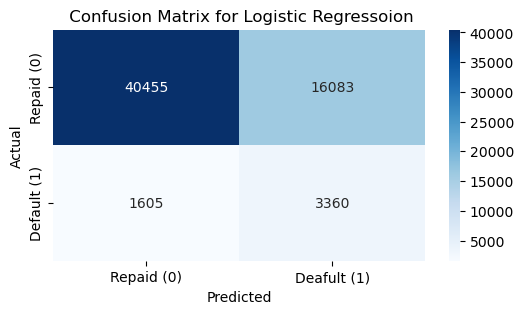

In [128]:
# app_train_features.info()

print('Confusion Matric (Random FOrest):')

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,3))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Repaid (0)','Deafult (1)'], yticklabels=['Repaid (0)','Default (1)'])
plt.title(' Confusion Matrix for Logistic Regressoion')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

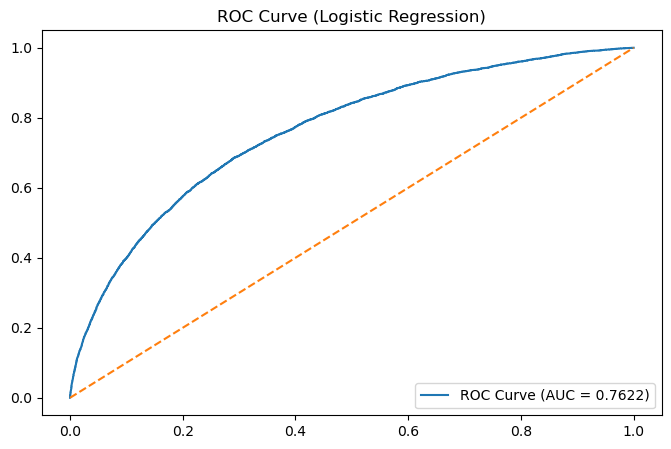

In [129]:
# roc curve

fpr_lr, tpr_lr, threshold_lr = roc_curve(y_test, y_probab_lr)


roc_auc_curve_lr = auc(fpr_lr,tpr_lr)


plt.figure(figsize=(8,5))
plt.plot(fpr_lr,tpr_lr, label=f'ROC Curve (AUC = {roc_auc_curve_lr:.4f})')
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel('')
plt.ylabel('')
plt.title('ROC Curve (Logistic Regression)')
plt.legend(loc='lower right')

### Random Forest Model

In [130]:
rf_model = RandomForestClassifier(
    random_state=42, n_estimators=100, class_weight='balanced_subsample', n_jobs=-1
)

rf_model.fit(x_train, y_train)


y_pred_rf = rf_model.predict(x_test)
y_probab_rf = rf_model.predict_proba(x_test)[:, 1]

In [131]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_probab_rf)


print(f'Accuracy: {accuracy_rf:.4f}')
print(f'Precision: {precision_rf:.4f}')
print(f'Recall: {recall_rf:.4f}')
print(f'F1-Score: {f1_rf:.4f}')
print(f'ROC AUC: {roc_auc_rf:.4f}')

# Accuracy: 0.9192
# Precision: 0.4091
# Recall: 0.0018
# F1-Score: 0.0036
# ROC AUC: 0.7349

Accuracy: 0.9192
Precision: 0.4286
Recall: 0.0012
F1-Score: 0.0024
ROC AUC: 0.7330


In [132]:
print('\n Classification Report (Random FOrest):')

print(classification_report(y_test, y_pred_rf))


 Classification Report (Random FOrest):
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.43      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.67      0.50      0.48     61503
weighted avg       0.88      0.92      0.88     61503



Confusion Matric (Random FOrest):


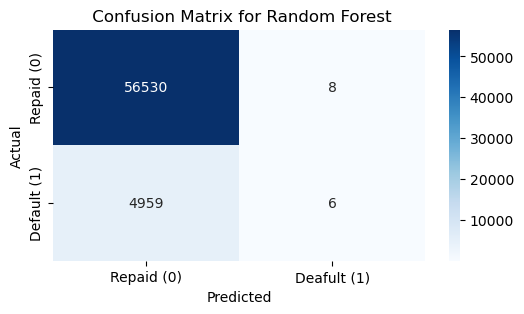

In [133]:
print('Confusion Matric (Random FOrest):')

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,3))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Repaid (0)','Deafult (1)'], yticklabels=['Repaid (0)','Default (1)'])
plt.title(' Confusion Matrix for Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

--- Identifying Important Factors (Feature Importance for Random Forest) ---


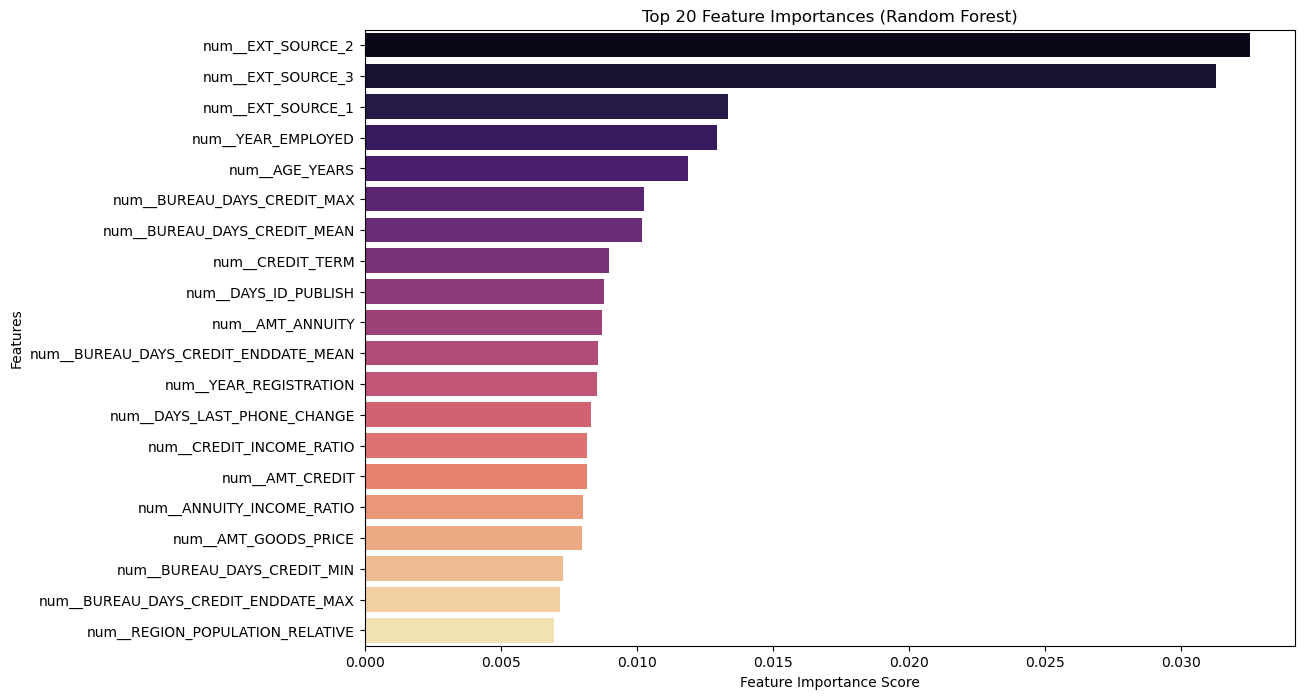


Top 20 Features from Random Forest:
num__EXT_SOURCE_2                       0.032556
num__EXT_SOURCE_3                       0.031281
num__EXT_SOURCE_1                       0.013363
num__YEAR_EMPLOYED                      0.012939
num__AGE_YEARS                          0.011876
num__BUREAU_DAYS_CREDIT_MAX             0.010267
num__BUREAU_DAYS_CREDIT_MEAN            0.010190
num__CREDIT_TERM                        0.008961
num__DAYS_ID_PUBLISH                    0.008787
num__AMT_ANNUITY                        0.008716
num__BUREAU_DAYS_CREDIT_ENDDATE_MEAN    0.008590
num__YEAR_REGISTRATION                  0.008540
num__DAYS_LAST_PHONE_CHANGE             0.008301
num__CREDIT_INCOME_RATIO                0.008161
num__AMT_CREDIT                         0.008153
num__ANNUITY_INCOME_RATIO               0.008010
num__AMT_GOODS_PRICE                    0.007971
num__BUREAU_DAYS_CREDIT_MIN             0.007282
num__BUREAU_DAYS_CREDIT_ENDDATE_MAX     0.007193
num__REGION_POPULATION_RELATIVE 

In [134]:
print("--- Identifying Important Factors (Feature Importance for Random Forest) ---")
if hasattr(rf_model, 'feature_importances_'):
    feature_importances_rf = pd.Series(rf_model.feature_importances_, index=x_train.columns)
    top_20_features_rf = feature_importances_rf.nlargest(20)

    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_20_features_rf.values, y=top_20_features_rf.index, palette='magma')
    plt.title('Top 20 Feature Importances (Random Forest)')
    plt.xlabel('Feature Importance Score')
    plt.ylabel('Features')
    plt.show()
    print("\nTop 20 Features from Random Forest:")
    print(top_20_features_rf)


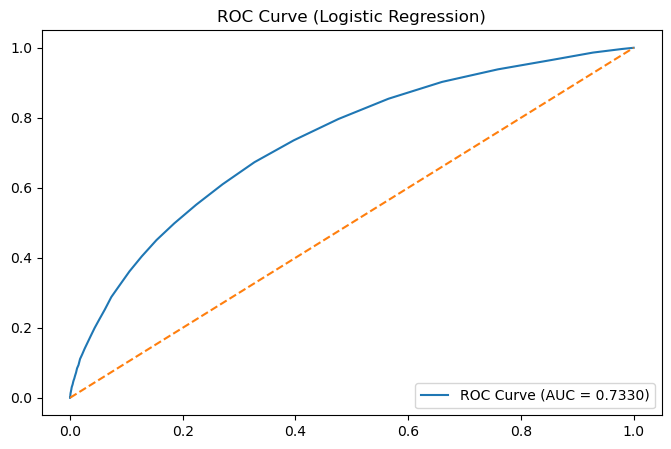

In [135]:
# roc curve for Random Forest

fpr_rf, tpr_rf, threshold = roc_curve(y_test, y_probab_rf)

roc_auc_curve_rf = auc(fpr_rf,tpr_rf)

plt.figure(figsize=(8,5))
plt.plot(fpr_rf,tpr_rf, label=f'ROC Curve (AUC = {roc_auc_curve_rf:.4f})')
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel('')
plt.ylabel('')
plt.title('ROC Curve (Logistic Regression)')
plt.legend(loc='lower right')

### LightGBM 

In [136]:
lgbm_model = LGBMClassifier(
    random_state=42,
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=64,
    colsample_bytree=0.9,
    subsample=0.9,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight='balanced',
    n_jobs=-1)

lgbm_model.fit(x_train, y_train)

y_pred_lgbm = lgbm_model.predict(x_test)
y_probab_lgbm = lgbm_model.predict_proba(x_test)[:, 1]

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069225 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 53682
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 426
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


In [137]:
accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)
precision_lgbm = precision_score(y_test, y_pred_lgbm)
recall_lgbm = recall_score(y_test, y_pred_lgbm)
f1_lgbm = f1_score(y_test, y_pred_lgbm)
roc_auc_lgbm = roc_auc_score(y_test, y_probab_lgbm)

print(f'Accuracy: {accuracy_lgbm:.4f}')
print(f'Precision: {precision_lgbm:.4f}')
print(f'Recall: {recall_lgbm:.4f}')
print(f'F1-Score: {f1_lgbm:.4f}')
print(f'ROC AUC: {roc_auc_lgbm:.4f}')

Accuracy: 0.8715
Precision: 0.2776
Recall: 0.3694
F1-Score: 0.3170
ROC AUC: 0.7626


In [138]:
print('\n Classification Report (LightGBM):')

print(classification_report(y_test, y_pred_lgbm))


 Classification Report (LightGBM):
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     56538
           1       0.28      0.37      0.32      4965

    accuracy                           0.87     61503
   macro avg       0.61      0.64      0.62     61503
weighted avg       0.89      0.87      0.88     61503



Confusion Matric (Lightgbm):


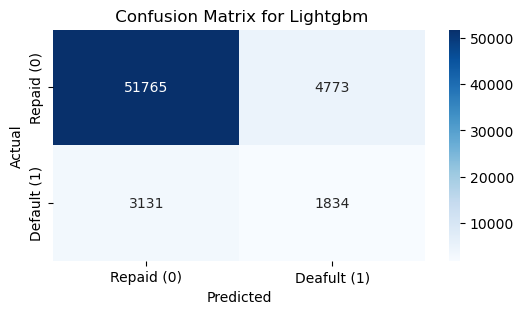

In [139]:
print('Confusion Matric (Lightgbm):')

cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

plt.figure(figsize=(6,3))

sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues', xticklabels=['Repaid (0)','Deafult (1)'], yticklabels=['Repaid (0)','Default (1)'])
plt.title(' Confusion Matrix for Lightgbm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

\--- Identifying Important Factors (Feature Importance for LightGBM) ---


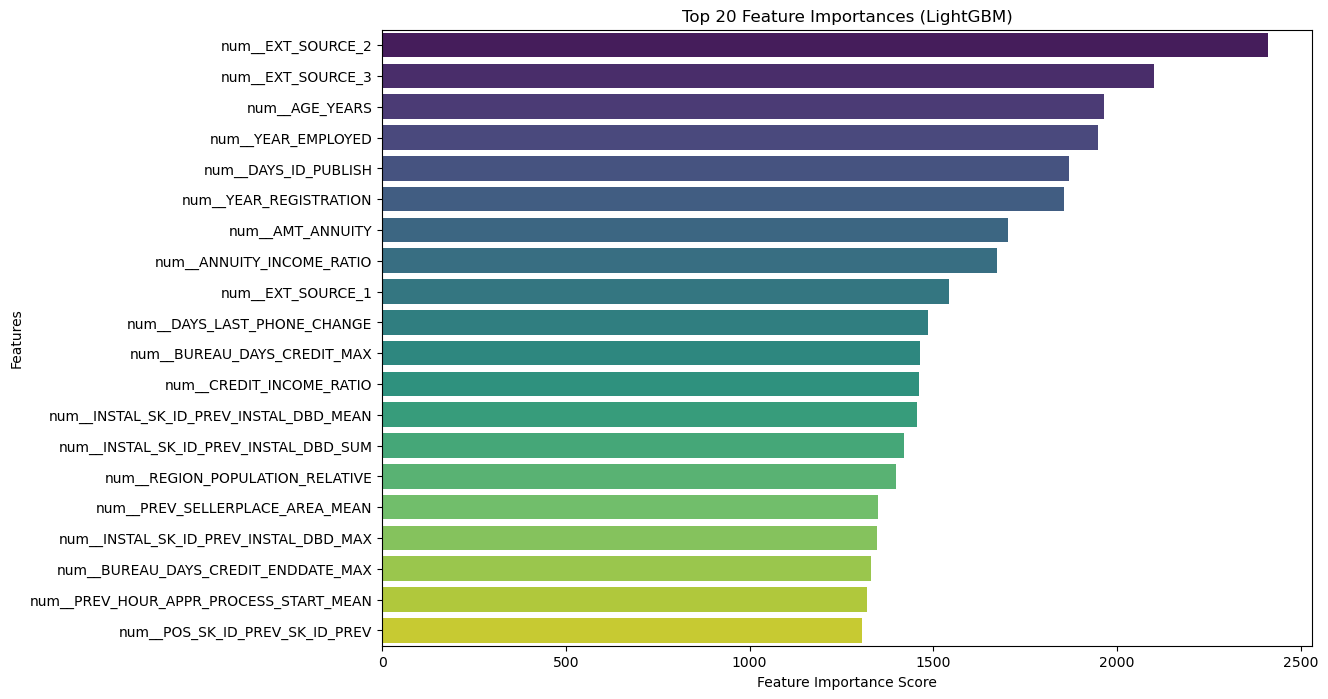

Top 20 Features from LightGBM:
num__EXT_SOURCE_2                         2411
num__EXT_SOURCE_3                         2101
num__AGE_YEARS                            1964
num__YEAR_EMPLOYED                        1949
num__DAYS_ID_PUBLISH                      1871
num__YEAR_REGISTRATION                    1855
num__AMT_ANNUITY                          1704
num__ANNUITY_INCOME_RATIO                 1674
num__EXT_SOURCE_1                         1544
num__DAYS_LAST_PHONE_CHANGE               1486
num__BUREAU_DAYS_CREDIT_MAX               1463
num__CREDIT_INCOME_RATIO                  1461
num__INSTAL_SK_ID_PREV_INSTAL_DBD_MEAN    1456
num__INSTAL_SK_ID_PREV_INSTAL_DBD_SUM     1421
num__REGION_POPULATION_RELATIVE           1400
num__PREV_SELLERPLACE_AREA_MEAN           1350
num__INSTAL_SK_ID_PREV_INSTAL_DBD_MAX     1346
num__BUREAU_DAYS_CREDIT_ENDDATE_MAX       1332
num__PREV_HOUR_APPR_PROCESS_START_MEAN    1319
num__POS_SK_ID_PREV_SK_ID_PREV            1306
dtype: int32


In [140]:
print("\--- Identifying Important Factors (Feature Importance for LightGBM) ---")
if hasattr(lgbm_model, 'feature_importances_'):
    feature_importances_lgbm = pd.Series(lgbm_model.feature_importances_, index=x_train.columns)
    top_20_features_lgbm = feature_importances_lgbm.nlargest(20)

    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_20_features_lgbm.values, y=top_20_features_lgbm.index, palette='viridis')
    plt.title('Top 20 Feature Importances (LightGBM)')
    plt.xlabel('Feature Importance Score')
    plt.ylabel('Features')
    plt.show()
    print("Top 20 Features from LightGBM:")
    print(top_20_features_lgbm)
    

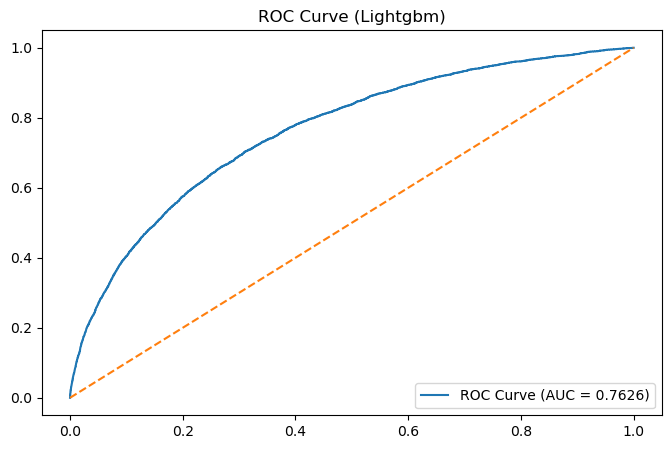

In [141]:
# roc curve for Lightgbm

fpr_lgbm, tpr_lgbm, threshold = roc_curve(y_test, y_probab_lgbm)

roc_auc_curve_lgbm = auc(fpr_lgbm,tpr_lgbm)

plt.figure(figsize=(8,5))
plt.plot(fpr_lgbm,tpr_lgbm, label=f'ROC Curve (AUC = {roc_auc_curve_lgbm:.4f})')
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel('')
plt.ylabel('')
plt.title('ROC Curve (Lightgbm)')
plt.legend(loc='lower right')

### XGBoost Model

removed this model because this model score was exactly same as the gradient boost model

### Gradient Boost Model

In [142]:
from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.ensemble import HistGradientBoostingClassifier

# gb_model = HistGradientBoostingClassifier(
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    subsample=0.8,
    max_features='sqrt',
    verbose=1
)


In [143]:
gb_model.fit(x_train, y_train)

y_pred_gb = gb_model.predict(x_test)
y_probab_gb = gb_model.predict_proba(x_test)[:, 1]

accuracy_gb= accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb =f1_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_probab_gb)

      Iter       Train Loss      OOB Improve   Remaining Time 
         1           0.5595           0.0023            2.76m
         2           0.5540           0.0028            2.57m
         3           0.5525           0.0018            2.58m
         4           0.5534           0.0019            2.54m
         5           0.5500           0.0024            2.49m
         6           0.5475           0.0012            2.45m
         7           0.5465           0.0019            2.42m
         8           0.5454           0.0013            2.39m
         9           0.5426           0.0019            2.40m
        10           0.5417           0.0014            2.38m
        20           0.5228           0.0011            2.30m
        30           0.5140           0.0008            2.24m
        40           0.5054           0.0005            2.17m
        50           0.5001           0.0007            2.08m
        60           0.4953           0.0003            1.98m
       

In [144]:
print(f'Accuracy: {accuracy_gb:.4f}')
print(f'Precision: {precision_gb:.4f}')
print(f'Recall: {recall_gb:.4f}')
print(f'F1-Score: {f1_gb:.4f}')
print(f'ROC AUC: {roc_auc_gb:.4f}')

# Accuracy: 0.9206
# Precision: 0.6389
# Recall: 0.0371
# F1-Score: 0.0701
# ROC AUC: 0.7802

Accuracy: 0.9206
Precision: 0.6389
Recall: 0.0371
F1-Score: 0.0701
ROC AUC: 0.7802


Confusion Matrix (Gradient Boost):


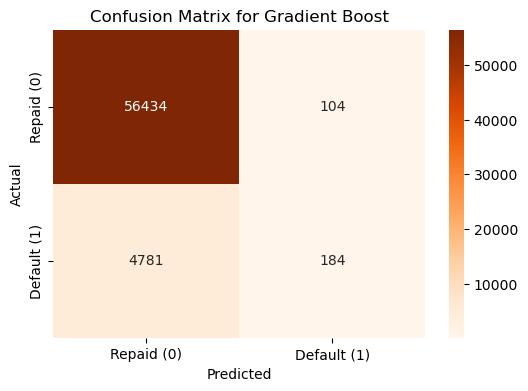

In [145]:
print("Confusion Matrix (Gradient Boost):")
cm_xgb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', xticklabels=['Repaid (0)', 'Default (1)'], yticklabels=['Repaid (0)', 'Default (1)'])
plt.title('Confusion Matrix for Gradient Boost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

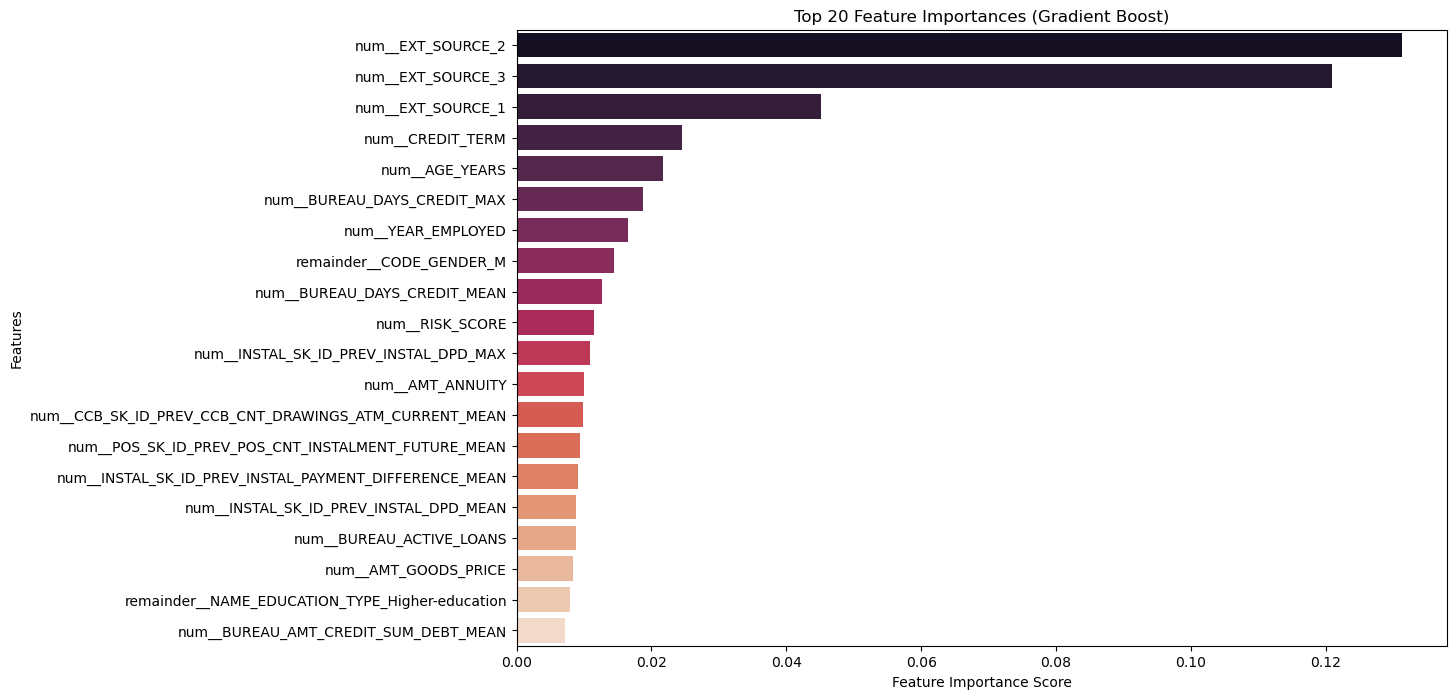

Top 20 Features from Gradient Boost:
num__EXT_SOURCE_2                                        0.131384
num__EXT_SOURCE_3                                        0.120967
num__EXT_SOURCE_1                                        0.045169
num__CREDIT_TERM                                         0.024551
num__AGE_YEARS                                           0.021770
num__BUREAU_DAYS_CREDIT_MAX                              0.018709
num__YEAR_EMPLOYED                                       0.016582
remainder__CODE_GENDER_M                                 0.014493
num__BUREAU_DAYS_CREDIT_MEAN                             0.012674
num__RISK_SCORE                                          0.011499
num__INSTAL_SK_ID_PREV_INSTAL_DPD_MAX                    0.010852
num__AMT_ANNUITY                                         0.009957
num__CCB_SK_ID_PREV_CCB_CNT_DRAWINGS_ATM_CURRENT_MEAN    0.009878
num__POS_SK_ID_PREV_POS_CNT_INSTALMENT_FUTURE_MEAN       0.009380
num__INSTAL_SK_ID_PREV_INSTAL_PAYMENT_D

In [146]:
if hasattr(gb_model, 'feature_importances_'):
    feature_importances_gb = pd.Series(gb_model.feature_importances_, index=x_train.columns)
    top_20_features_gb = feature_importances_gb.nlargest(20)

    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_20_features_gb.values, y=top_20_features_gb.index, palette='rocket')
    plt.title('Top 20 Feature Importances (Gradient Boost)')
    plt.xlabel('Feature Importance Score')
    plt.ylabel('Features')
    plt.show()
    print("Top 20 Features from Gradient Boost:")
    print(top_20_features_gb)

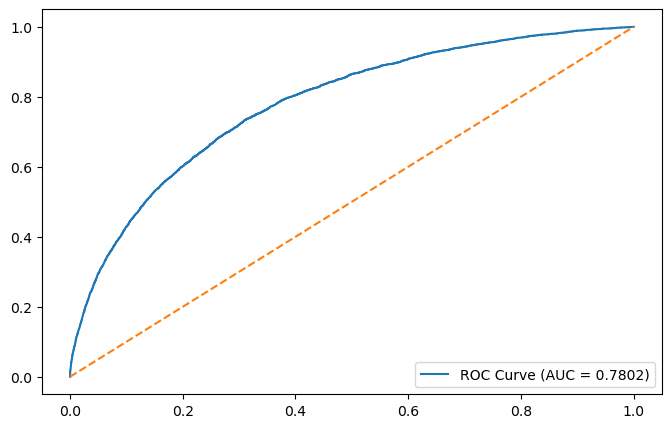

In [147]:

fpr_gb, tpr_gb, threshold_gb = roc_curve(y_test, y_probab_gb)

roc_auc_curve_gb = auc(fpr_gb,tpr_gb)

plt.figure(figsize=(8,5))
plt.plot(fpr_gb,tpr_gb, label=f'ROC Curve (AUC = {roc_auc_curve_gb:.4f})')
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel('')
plt.ylabel('')
plt.title('')
plt.legend(loc='lower right')

### K-Nearest Nieghbor Model

In [148]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
        n_neighbors=500,
        weights='uniform',
        algorithm='auto',
        leaf_size=30,
        p=2,
        metric='minkowski',
        n_jobs=-1
)

In [149]:
knn_model.fit(x_train_smote, y_train_smote)

y_pred_knn = knn_model.predict(x_test)
y_probab_knn = knn_model.predict_proba(x_test)[:, 1]

accuracy_knn= accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn =f1_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_probab_knn)

In [150]:
print(f'Accuracy: {accuracy_knn:.4f}')
print(f'Precision: {precision_knn:.4f}')
print(f'Recall: {recall_knn:.4f}')
print(f'F1-Score: {f1_knn:.4f}')
print(f'ROC AUC: {roc_auc_knn:.4f}')

Accuracy: 0.1678
Precision: 0.0862
Recall: 0.9702
F1-Score: 0.1584
ROC AUC: 0.6749


Confusion Matrix (K-Nearest Neighbor):


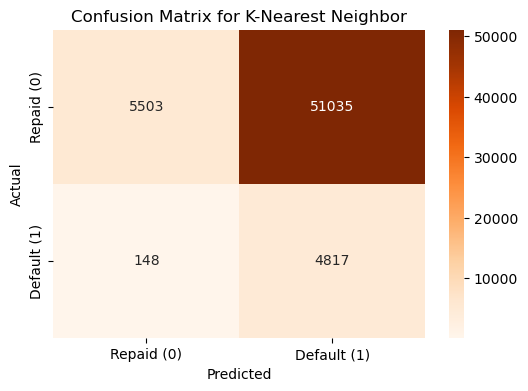

In [151]:
print("Confusion Matrix (K-Nearest Neighbor):")
cm_xgb = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', xticklabels=['Repaid (0)', 'Default (1)'], yticklabels=['Repaid (0)', 'Default (1)'])
plt.title('Confusion Matrix for K-Nearest Neighbor')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

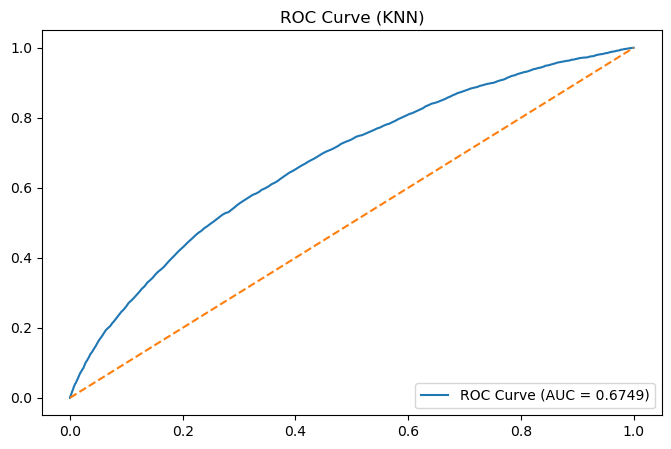

In [152]:
fpr_knn, tpr_knn, threshold = roc_curve(y_test, y_probab_knn)

roc_auc_curve_knn = auc(fpr_knn,tpr_knn)

plt.figure(figsize=(8,5))
plt.plot(fpr_knn,tpr_knn, label=f'ROC Curve (AUC = {roc_auc_curve_knn:.4f})')
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel('')
plt.ylabel('')
plt.title('ROC Curve (KNN)')
plt.legend(loc='lower right')

### CatBoost Model

In [153]:
from catboost import CatBoostClassifier

In [154]:
cat_model = CatBoostClassifier(
    random_state=42,
    verbose = 1,
    learning_rate=0.05,
    iterations = 1000,
    depth = 8,
    loss_function = 'Logloss',
    eval_metric='AUC',
    class_weights=[1,10],

)

In [155]:
# cat_model.fit(x_train_smote, y_train_smote)

cat_model.fit(x_train, y_train) # without smote or with imbalance data
# without smote catboost result is great


y_pred_cat = cat_model.predict(x_test)
y_probab_cat = cat_model.predict_proba(x_test)[:, 1]

accuracy_cat= accuracy_score(y_test, y_pred_cat)
precision_cat = precision_score(y_test, y_pred_cat)
recall_cat = recall_score(y_test, y_pred_cat)
f1_cat =f1_score(y_test, y_pred_cat)
roc_auc_cat = roc_auc_score(y_test, y_probab_cat)

0:	total: 197ms	remaining: 3m 17s
1:	total: 298ms	remaining: 2m 28s
2:	total: 388ms	remaining: 2m 9s
3:	total: 487ms	remaining: 2m 1s
4:	total: 582ms	remaining: 1m 55s
5:	total: 681ms	remaining: 1m 52s
6:	total: 783ms	remaining: 1m 51s
7:	total: 877ms	remaining: 1m 48s
8:	total: 971ms	remaining: 1m 46s
9:	total: 1.07s	remaining: 1m 45s
10:	total: 1.17s	remaining: 1m 45s
11:	total: 1.28s	remaining: 1m 45s
12:	total: 1.39s	remaining: 1m 45s
13:	total: 1.49s	remaining: 1m 45s
14:	total: 1.59s	remaining: 1m 44s
15:	total: 1.71s	remaining: 1m 45s
16:	total: 1.88s	remaining: 1m 48s
17:	total: 2s	remaining: 1m 49s
18:	total: 2.1s	remaining: 1m 48s
19:	total: 2.2s	remaining: 1m 47s
20:	total: 2.31s	remaining: 1m 47s
21:	total: 2.42s	remaining: 1m 47s
22:	total: 2.53s	remaining: 1m 47s
23:	total: 2.66s	remaining: 1m 48s
24:	total: 2.79s	remaining: 1m 48s
25:	total: 2.9s	remaining: 1m 48s
26:	total: 3.02s	remaining: 1m 48s
27:	total: 3.11s	remaining: 1m 48s
28:	total: 3.21s	remaining: 1m 47s
29:

In [156]:
print(f'Accuracy: {accuracy_cat:.4f}')
print(f'Precision: {precision_cat:.4f}')
print(f'Recall: {recall_cat:.4f}')
print(f'F1-Score: {f1_cat:.4f}')
print(f'ROC AUC: {roc_auc_cat:.4f}')

Accuracy: 0.8104
Precision: 0.2290
Recall: 0.5700
F1-Score: 0.3268
ROC AUC: 0.7837


Confusion Matrix (Cat Model):


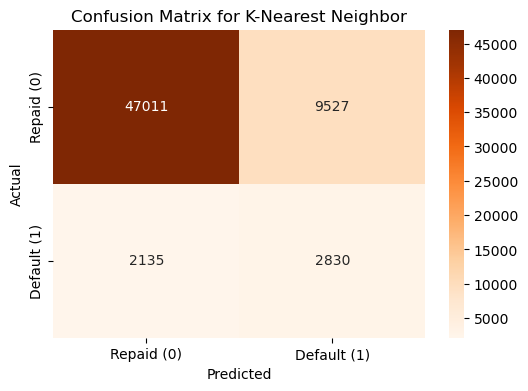

In [157]:
print("Confusion Matrix (Cat Model):")
cm_xgb = confusion_matrix(y_test, y_pred_cat)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', xticklabels=['Repaid (0)', 'Default (1)'], yticklabels=['Repaid (0)', 'Default (1)'])
plt.title('Confusion Matrix for K-Nearest Neighbor')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

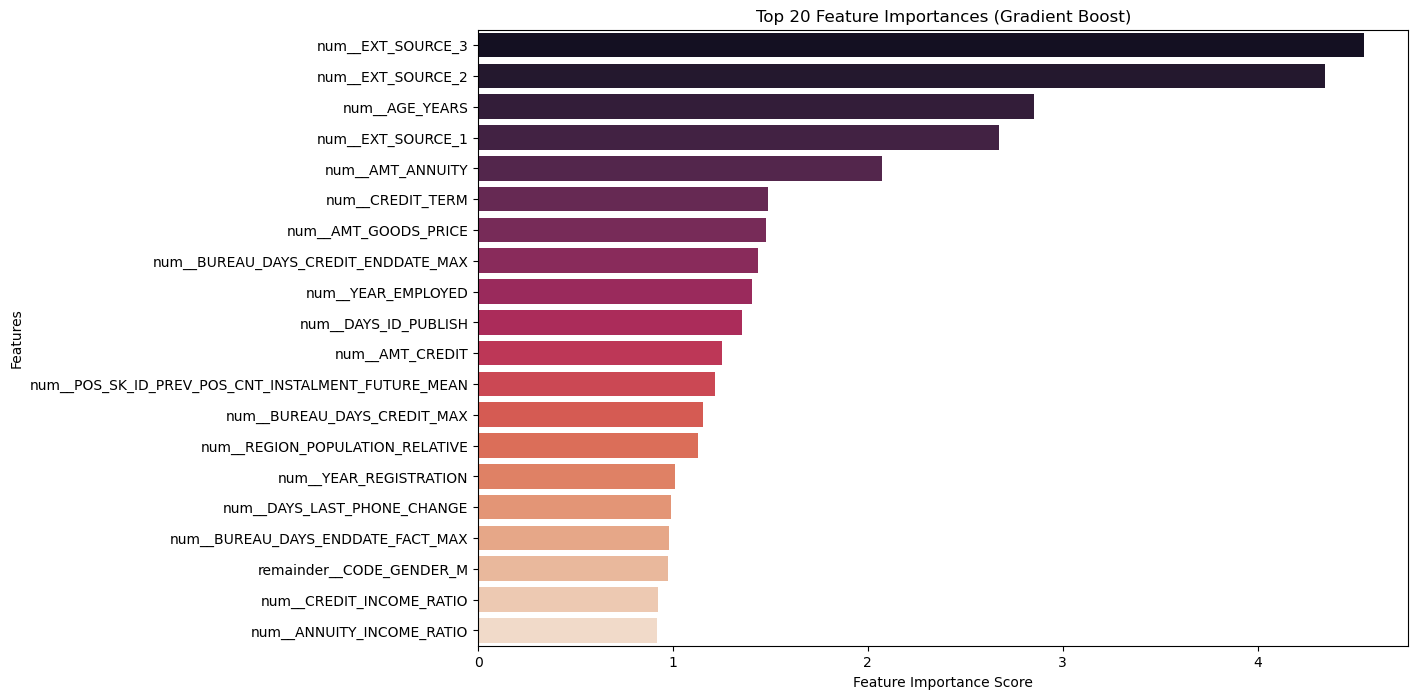

In [158]:
if hasattr(gb_model, 'feature_importances_'):
    feature_importances_cat = pd.Series(cat_model.feature_importances_, index=x_train.columns)
    top_20_features_cat = feature_importances_cat.nlargest(20)

    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_20_features_cat.values, y=top_20_features_cat.index, palette='rocket')
    plt.title('Top 20 Feature Importances (Gradient Boost)')
    plt.xlabel('Feature Importance Score')
    plt.ylabel('Features')
    plt.show()
    # print("Top 20 Features from Gradient Boost:")
    # print(top_20_features_cat)

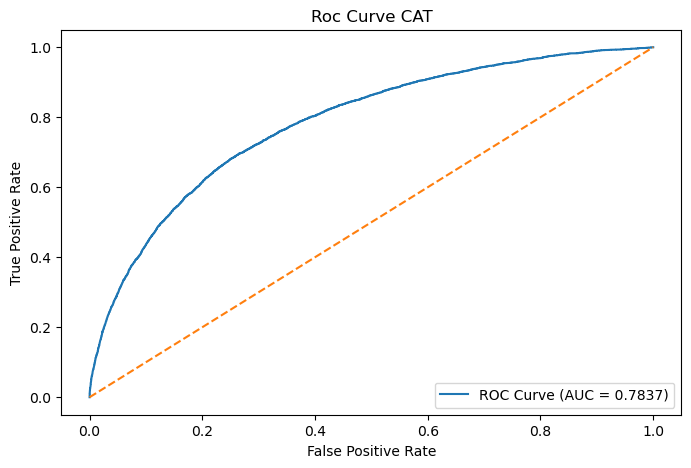

In [159]:
# ROC Curve

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


fpr_cat, tpr_cat, threshold = roc_curve(y_test, y_probab_cat)

roc_auc_curve_cat = auc(fpr_cat,tpr_cat)

plt.figure(figsize=(8,5))
plt.plot(fpr_cat,tpr_cat, label=f'ROC Curve (AUC = {roc_auc_curve_cat:.4f})')
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Roc Curve CAT')
plt.legend(loc='lower right')

### Combining score 

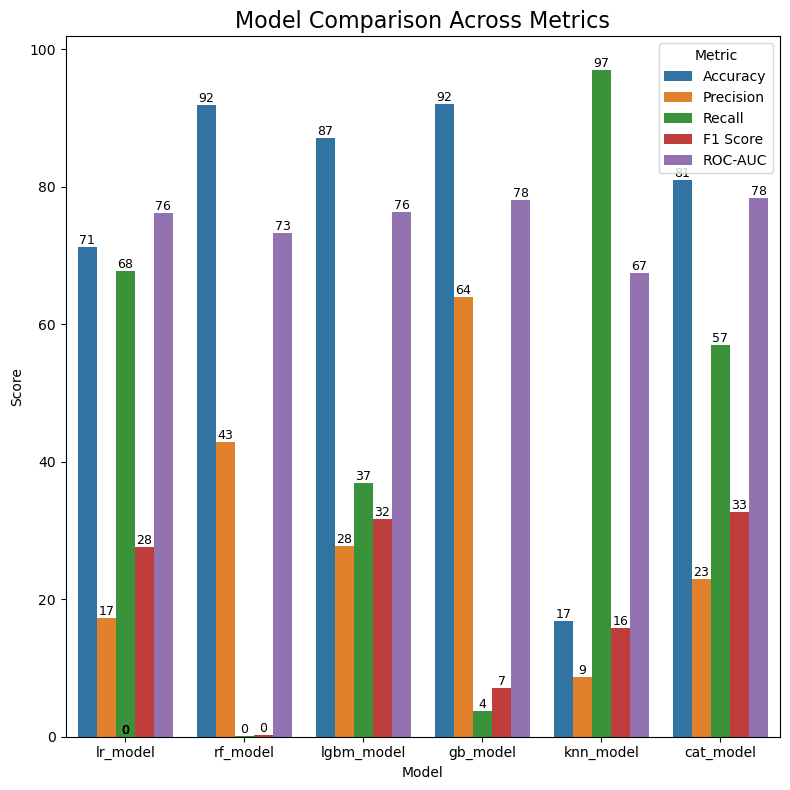

In [160]:
data = {
    'Model' : ['lr_model', 'rf_model', 'lgbm_model', 'gb_model', 'knn_model', 'cat_model'],
    'Accuracy': [accuracy_lr, accuracy_rf, accuracy_lgbm, accuracy_gb, accuracy_knn, accuracy_cat],
    'Precision': [precision_lr, precision_rf, precision_lgbm, precision_gb,  precision_knn, precision_cat],
    'Recall': [recall_lr, recall_rf, recall_lgbm, recall_gb, recall_knn, recall_cat],
    'F1 Score': [f1_lr, f1_rf, f1_lgbm, f1_gb, f1_knn, f1_cat],
    'ROC-AUC': [roc_auc_lr, roc_auc_rf, roc_auc_lgbm, roc_auc_gb, roc_auc_knn, roc_auc_cat],
    # 'ROC-Curve': [(fpr_lr, tpr_lr), (fpr_rf, tpr_rf), (fpr_lgbm, tpr_lgbm),(fpr_gb, tpr_gb), (fpr_knn, tpr_knn), (fpr_cat, tpr_cat)]
}



plot_data = pd.DataFrame(data)

df_melt = plot_data.melt(id_vars="Model", var_name="Metric", value_name="Score")
df_melt['Score'] = df_melt['Score']* 100


plt.figure(figsize=(8, 8))
bar_fig = sns.barplot(data=df_melt, x="Model", y="Score", hue="Metric")

for i in bar_fig.patches:
    height=i.get_height()
    x_pos = i.get_x() + i.get_width() /2
    bar_fig.text(x_pos,height  + .001, f'{height:.0f}', ha='center', va='bottom',fontsize=9)

plt.title("Model Comparison Across Metrics", fontsize=16)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("roc_curve_comparison.png")
plt.show()

1. We can see from the comparisons of accuracy, F1 score and AUC ROC scores that all models have different rankings.
2. The Gradient Boost and Random Forest models have highest accuracy, but the lowest F1 scores. This shows that they do not work well for imbalanced data.
3. The CatBoost and LightGBM classifiers give good F1 and AUC ROC results.
4. The AUC ROC scores can be better visualized using the ROC curves.

92% accuracy of look amazing but their Recall it is near 0.

This means they are predicting "No default" for everyone. These are pointless and useless number.

SO in banking, bank are afraid of losing money, so they need to catch the defaulters (one who could not repay back to bank ).

So a high number on Recall means bank caught the bad guys.


Best Model : **CatBoost Model**

1. Recall is at 62% of the defaulter
2. ROC-AUC is 77
3. Accuracy is 76%

Why Gradient Boost and Random Forest is not best model because of precision score and recall is near to 0, and it High False Positive. Model learned 92% of people pay back loan, but it failed to learn what a defaulter look like.

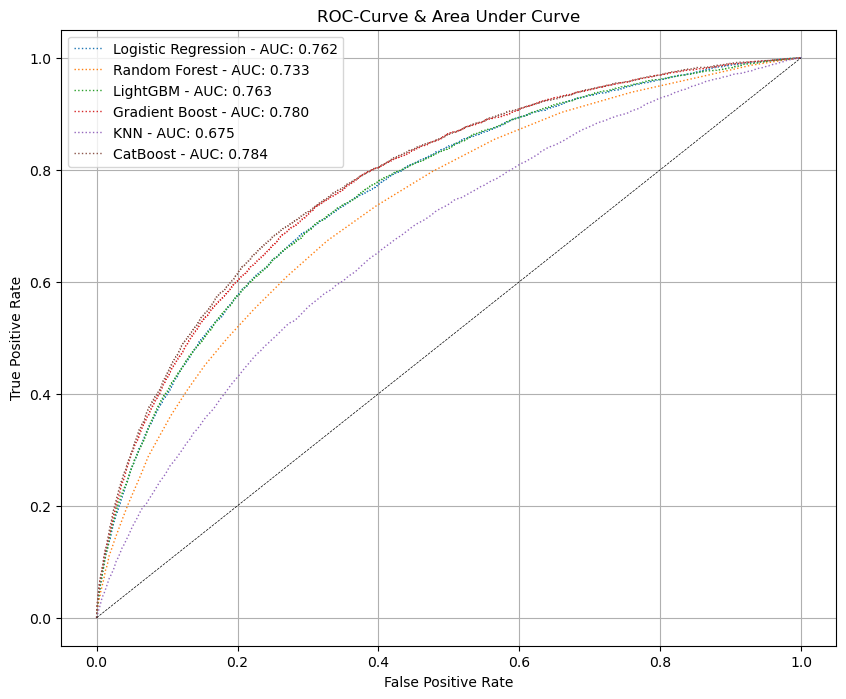

In [161]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111)

ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression - AUC: {roc_auc_lr:.3f}',
        linewidth=1, linestyle="dotted")


ax.plot(fpr_rf, tpr_rf, label=f'Random Forest - AUC: {roc_auc_rf:.3f}',
        linewidth=1, linestyle="dotted")


ax.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM - AUC: {roc_auc_lgbm:.3f}',
        linewidth=1, linestyle="dotted")


ax.plot(fpr_gb, tpr_gb, label=f'Gradient Boost - AUC: {roc_auc_gb:.3f}',
        linewidth=1, linestyle="dotted")


ax.plot(fpr_knn, tpr_knn, label=f'KNN - AUC: {roc_auc_knn:.3f}',
        linewidth=1, linestyle="dotted")


ax.plot(fpr_cat, tpr_cat, label=f'CatBoost - AUC: {roc_auc_cat:.3f}',
        linewidth=1, linestyle="dotted")

# Random guess line
ax.plot([0,1], [0,1], linewidth=0.5, linestyle="dashed", color='k')

plt.legend(loc="best")
plt.title("ROC-Curve & Area Under Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.show()


### Hyper parameter tuning

In [162]:
# from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV



In [163]:
# iteration are lower because it take too much time 

cat_model_2 = CatBoostClassifier(
    random_state=42,
    loss_function='Logloss',
    eval_metric='AUC',
    class_weights=[1,10],
    verbose=1
)


cat_param = {
    'iterations' : [500],
    'depth': [4,6,8],
    'learning_rate': [0.03,0.05,0.1],
    'l2_leaf_reg':[1,3,5],
    'border_count': [128],
    'bagging_temperature': [0, 0.5, 1]
}

cat_grid = RandomizedSearchCV(
    estimator= cat_model_2,
    param_distributions =  cat_param,
    n_iter= 6,
    cv = 3,
    scoring = 'roc_auc',
    n_jobs=-1,
    verbose=2,
    random_state=42,
    return_train_score=True
)




In [164]:
cat_grid.fit(x_train, y_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
0:	total: 144ms	remaining: 1m 11s
1:	total: 227ms	remaining: 56.6s
2:	total: 320ms	remaining: 53s
3:	total: 401ms	remaining: 49.7s
4:	total: 514ms	remaining: 50.9s
5:	total: 603ms	remaining: 49.6s
6:	total: 687ms	remaining: 48.4s
7:	total: 760ms	remaining: 46.7s
8:	total: 843ms	remaining: 46s
9:	total: 940ms	remaining: 46.1s
10:	total: 1.01s	remaining: 45.1s
11:	total: 1.09s	remaining: 44.5s
12:	total: 1.18s	remaining: 44.1s
13:	total: 1.25s	remaining: 43.6s
14:	total: 1.34s	remaining: 43.3s
15:	total: 1.42s	remaining: 43s
16:	total: 1.51s	remaining: 42.9s
17:	total: 1.59s	remaining: 42.6s
18:	total: 1.67s	remaining: 42.3s
19:	total: 1.76s	remaining: 42.3s
20:	total: 1.85s	remaining: 42.3s
21:	total: 1.94s	remaining: 42.3s
22:	total: 2.03s	remaining: 42.1s
23:	total: 2.35s	remaining: 46.7s
24:	total: 2.67s	remaining: 50.8s
25:	total: 2.88s	remaining: 52.5s
26:	total: 3.09s	remaining: 54.1s
27:	total: 3.41s	remaining: 57.6s
28:

RandomizedSearchCV(cv=3,
                   estimator=<catboost.core.CatBoostClassifier object at 0x33e49c950>,
                   n_iter=6, n_jobs=-1,
                   param_distributions={'bagging_temperature': [0, 0.5, 1],
                                        'border_count': [128],
                                        'depth': [4, 6, 8], 'iterations': [500],
                                        'l2_leaf_reg': [1, 3, 5],
                                        'learning_rate': [0.03, 0.05, 0.1]},
                   random_state=42, return_train_score=True, scoring='roc_auc',
                   verbose=2)

In [165]:
best_cat = cat_grid.best_estimator_

#evaluate 
y_pred_probab_tune_cat = best_cat.predict_proba(x_test)[:, 1]


auc_cat_tuned = roc_auc_score(y_test, y_pred_probab_tune_cat)


In [166]:
print(auc_cat_tuned)

0.7817503770868826


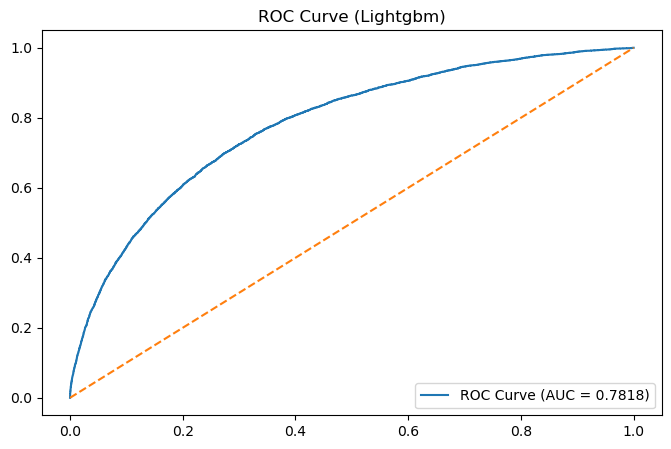

In [167]:
fpr_tuned_cat, tpr_tuned_cat, threshold = roc_curve(y_test, y_pred_probab_tune_cat)

roc_auc_curve_tuned_cat = auc(fpr_tuned_cat,tpr_tuned_cat)

plt.figure(figsize=(8,5))
plt.plot(fpr_tuned_cat,tpr_tuned_cat, label=f'ROC Curve (AUC = {roc_auc_curve_tuned_cat:.4f})')
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel('')
plt.ylabel('')
plt.title('ROC Curve (Lightgbm)')
plt.legend(loc='lower right')

This roc curve is after tuning cat model , model only increases by 1 percentage.

In [168]:
best_cat.fit(x_train, y_train)

0:	total: 69ms	remaining: 34.5s
1:	total: 135ms	remaining: 33.5s
2:	total: 197ms	remaining: 32.6s
3:	total: 264ms	remaining: 32.7s
4:	total: 333ms	remaining: 32.9s
5:	total: 394ms	remaining: 32.5s
6:	total: 463ms	remaining: 32.6s
7:	total: 530ms	remaining: 32.6s
8:	total: 594ms	remaining: 32.4s
9:	total: 662ms	remaining: 32.4s
10:	total: 728ms	remaining: 32.3s
11:	total: 794ms	remaining: 32.3s
12:	total: 866ms	remaining: 32.5s
13:	total: 929ms	remaining: 32.3s
14:	total: 990ms	remaining: 32s
15:	total: 1.05s	remaining: 31.9s
16:	total: 1.12s	remaining: 31.8s
17:	total: 1.2s	remaining: 32s
18:	total: 1.27s	remaining: 32.1s
19:	total: 1.33s	remaining: 31.9s
20:	total: 1.39s	remaining: 31.8s
21:	total: 1.46s	remaining: 31.7s
22:	total: 1.52s	remaining: 31.6s
23:	total: 1.59s	remaining: 31.5s
24:	total: 1.66s	remaining: 31.6s
25:	total: 1.72s	remaining: 31.4s
26:	total: 1.78s	remaining: 31.2s
27:	total: 1.83s	remaining: 30.9s
28:	total: 1.9s	remaining: 30.9s
29:	total: 1.97s	remaining: 30.

In [169]:
import joblib
joblib.dump(best_cat, "catboost_loan_default.pkl")

['catboost_loan_default.pkl']

In this project, multiple machine learning models were developed and evaluated to predict loan default risk. After hyperparameter tuning and comparative analysis using ROC-AUC, precision, recall, and f1-score, CAtBoosst emerged as the most balanced and stable model. ALthough the ROC-AUC values were below 0.80, the model demonstrated consistent performance on unseen test data, indicating realistic behavious for a real-world banking dataset. Threshold optimization was applied analysis provised busines insight into key drivers of loan default.

To address class imbalance in the loan default dataset, SMOTE was initally applied to balance the target classes. This approach helped increase the representation of default cases in only few model and was evaluated few multiple models. However after comparative analysis, it was observed that models trained without SMOTE achieved better score on unseen test data.
Therefore, SMOTE was not used in the final model to avoid potential overfitting, ensuring more stable and realistic


Both Logistic Regression and CatBoost performed excellently, achieving ~77% ROC-AUC.

* If the bank wants to minimize risk at all costs, Logistic Regression is the best choice (Highest Recall).
* However, CatBoost is the recommended final model because it offers a better balance—it detects risk effectively while falsely rejecting fewer good customers (Higher Accuracy & Precision).

**The final CatBoost model was saved and is suitable for deployment in a production**